In [49]:
import glob
import numpy as np
import pandas as pd

import torch
import wandb
from model import LightningWBoson
from data_module import WBosonDataModule
from load_data import load_data
import ll_train

from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm, Normalize
import seaborn as sns
import mplhep as hep

hep.style.use(hep.style.ATLAS)

In [50]:
ll_data_path = "/root/data/mc20_truth_LL.h5"
sm_data_path = "/root/data/mc20_truth_v4_SM.h5"
wandb_path = "saved_w_boson_regressor_ll"
ckpt_files = glob.glob(f"/root/work/QE-mls/QE-torch/PcRes/{wandb_path}/*/checkpoints/*.ckpt")
if not ckpt_files: 
    raise FileNotFoundError(f"No checkpoint files found in {wandb_path}/checkpoints/")
ckpt_path = ckpt_files[0]  # Use the first checkpoint found
print(f"Using checkpoint: {ckpt_path}")


Using checkpoint: /root/work/QE-mls/QE-torch/PcRes/saved_w_boson_regressor_ll/o9vuog1y/checkpoints/reg-epoch=414-val_loss=34.48.ckpt


In [51]:
# Retrieve datamodule used in training
dm = ll_train.main(train=False)
# Load model from checkpoint
model = LightningWBoson.load_from_checkpoint(ckpt_path)
model.eval() # used to inference -> not for training phase

# Set up the data module (prepare data and setup splits)
dm.setup(stage="test")  # Ensure test dataset is ready
# Get the test dataloader
test_loader = dm.test_dataloader()

# Run inference
predictions = np.empty([0, dm.X.shape[1]-2]) # without including W0 and W1 mass
true_labels = np.empty([0, dm.Y.shape[1]])
train_features = np.empty([0, dm.X.shape[1]])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

with torch.no_grad():  # Disable gradient computation for inference
    for batch in test_loader:
        # Assuming batch contains inputs and targets
        inputs, targets = batch
        inputs = inputs.to(device)
        targets = targets.to(device)
        
        # Forward pass
        outputs = model(inputs)
        
        # Store predictions and true labels
        train_features = np.append(train_features, inputs.cpu().numpy(), axis=0)
        predictions = np.append(predictions, outputs.cpu().numpy(), axis=0)
        true_labels = np.append(true_labels, targets.cpu().numpy(), axis=0)

Evaluation mode, loading checkpoints...
Training objects shape: (649710, 10)
Target objects shape: (649710, 10)
Loading model from checkpoint for evaluation... return datamodule


In [52]:
# SM sample
train_obj, target_obj = load_data(sm_data_path)
X = train_obj.astype(np.float32)
Y = target_obj.astype(np.float32)
input_dim = X.shape[1]
dm = WBosonDataModule(
    X, Y,
    batch_size=ll_train.BATCH_SIZE,
    num_workers=8,
    val_frac=0.1,
    test_frac=0.1
)
dm.setup(stage="test")
test_loader = dm.test_dataloader()

sm_predictions = np.empty([0, dm.X.shape[1]-2])
sm_true_labels = np.empty([0, dm.Y.shape[1]])
sm_train_features = np.empty([0, dm.X.shape[1]])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()
with torch.no_grad():
    for batch in test_loader:
        inputs, targets = batch
        inputs = inputs.to(device)
        targets = targets.to(device)
        
        outputs = model(inputs)
        
        sm_train_features = np.append(sm_train_features, inputs.cpu().numpy(), axis=0)
        sm_predictions = np.append(sm_predictions, outputs.cpu().numpy(), axis=0)
        sm_true_labels = np.append(sm_true_labels, targets.cpu().numpy(), axis=0)

Training objects shape: (1460585, 10)
Target objects shape: (1460585, 10)


In [53]:
def pt(px, py):
    return np.sqrt(np.square(px) + np.square(py))


def eta(px, py, pz):
    pt = np.sqrt(np.square(px) + np.square(py))
    return np.arcsinh(np.divide(pz, pt))


def phi(px, py):
    return np.arctan2(py, px)

In [54]:
# SM training features
lep0_px = train_features[:, 0]
lep0_py = train_features[:, 1]
lep0_pz = train_features[:, 2]
lep0_energy = train_features[:, 3]
lep0_p3 = np.vstack((lep0_px, lep0_py, lep0_pz)).T
lep1_px = train_features[:, 4]
lep1_py = train_features[:, 5]
lep1_pz = train_features[:, 6]
lep1_p3 = np.vstack((lep1_px, lep1_py, lep1_pz)).T
lep1_energy = train_features[:, 7]
met_px = train_features[:, 8]
met_py = train_features[:, 9]

# LL training features
sm_lep0_px = sm_train_features[:, 0]
sm_lep0_py = sm_train_features[:, 1]
sm_lep0_pz = sm_train_features[:, 2]
sm_lep0_p3 = np.vstack((sm_lep0_px, sm_lep0_py, sm_lep0_pz)).T
sm_lep0_energy = sm_train_features[:, 3]
sm_lep1_px = sm_train_features[:, 4]
sm_lep1_py = sm_train_features[:, 5]
sm_lep1_pz = sm_train_features[:, 6]
sm_lep1_p3 = np.vstack((sm_lep1_px, sm_lep1_py, sm_lep1_pz)).T
sm_lep1_energy = sm_train_features[:, 7]
sm_met_px = sm_train_features[:, 8]
sm_met_py = sm_train_features[:, 9]

In [58]:
# LL

pred_w0_px = predictions[..., 0]
pred_w0_py = predictions[..., 1]
pred_w0_pz = predictions[..., 2]
pred_w0_p3 = np.vstack((pred_w0_px, pred_w0_py, pred_w0_pz)).T
pred_w0_energy = predictions[..., 3]
pred_w1_px = predictions[..., 4]
pred_w1_py = predictions[..., 5]
pred_w1_pz = predictions[..., 6]
pred_w1_p3 = np.vstack((pred_w1_px, pred_w1_py, pred_w1_pz)).T
pred_w1_energy = predictions[..., 7]
pred_w0_mass_2 = pred_w0_energy**2 - (pred_w0_px**2 + pred_w0_py**2 + pred_w0_pz**2)
pred_w1_mass_2 = pred_w1_energy**2 - (pred_w1_px**2 + pred_w1_py**2 + pred_w1_pz**2)
# diff rep
pred_w0_pt = pt(pred_w0_px, pred_w0_py)
pred_w0_eta = eta(pred_w0_px, pred_w0_py, pred_w0_pz)
pred_w0_phi = phi(pred_w0_px, pred_w0_py)
pred_w1_pt = pt(pred_w1_px, pred_w1_py)
pred_w1_eta = eta(pred_w1_px, pred_w1_py, pred_w1_pz)
pred_w1_phi = phi(pred_w1_px, pred_w1_py)

true_w0_px = true_labels[..., 0]
true_w0_py = true_labels[..., 1]
true_w0_pz = true_labels[..., 2]
true_w0_p3 = np.vstack((true_w0_px, true_w0_py, true_w0_pz)).T
true_w0_energy = true_labels[..., 3]
true_w1_px = true_labels[..., 4]
true_w1_py = true_labels[..., 5]
true_w1_pz = true_labels[..., 6]
true_w1_p3 = np.vstack((true_w1_px, true_w1_py, true_w1_pz)).T
true_w1_energy = true_labels[..., 7]
true_w0_mass_2 = true_labels[..., 8] ** 2
true_w1_mass_2 = true_labels[..., 9] ** 2
# diff rep
true_w0_pt = pt(true_w0_px, true_w0_py)
true_w0_eta = eta(true_w0_px, true_w0_py, true_w0_pz)
true_w0_phi = phi(true_w0_px, true_w0_py)
true_w1_pt = pt(true_w1_px, true_w1_py)
true_w1_eta = eta(true_w1_px, true_w1_py, true_w1_pz)
true_w1_phi = phi(true_w1_px, true_w1_py)

# lab frame directional cosine between parent W and decay lepton
true_lab_xi0 = np.sum(lep0_p3 * true_w0_p3, axis=1) / (np.linalg.norm(lep0_p3, axis=1) * np.linalg.norm(true_w0_p3, axis=1))
true_lab_xi1 = np.sum(lep1_p3 * true_w0_p3, axis=1) / (np.linalg.norm(lep1_p3, axis=1) * np.linalg.norm(true_w0_p3, axis=1))
pred_lab_xi0 = np.sum(lep0_p3 * pred_w0_p3, axis=1) / (np.linalg.norm(lep0_p3, axis=1) * np.linalg.norm(pred_w0_p3, axis=1))
pred_lab_xi1 = np.sum(lep1_p3 * pred_w0_p3, axis=1) / (np.linalg.norm(lep1_p3, axis=1) * np.linalg.norm(pred_w0_p3, axis=1))

In [59]:
# SM

sm_pred_w0_px = sm_predictions[..., 0]
sm_pred_w0_py = sm_predictions[..., 1]
sm_pred_w0_pz = sm_predictions[..., 2]
sm_pred_w0_p3 = np.vstack((sm_pred_w0_px, sm_pred_w0_py, sm_pred_w0_pz)).T
sm_pred_w0_energy = sm_predictions[..., 3]
sm_pred_w1_px = sm_predictions[..., 4]
sm_pred_w1_py = sm_predictions[..., 5]
sm_pred_w1_pz = sm_predictions[..., 6]
sm_pred_w1_p3 = np.vstack((sm_pred_w1_px, sm_pred_w1_py, sm_pred_w1_pz)).T
sm_pred_w1_energy = sm_predictions[..., 7]
sm_pred_w0_mass_2 = sm_pred_w0_energy**2 - (sm_pred_w0_px**2 + sm_pred_w0_py**2 + sm_pred_w0_pz**2)
sm_pred_w1_mass_2 = sm_pred_w1_energy**2 - (sm_pred_w1_px**2 + sm_pred_w1_py**2 + sm_pred_w1_pz**2)
# diff rep
sm_pred_w0_pt = pt(sm_pred_w0_px, sm_pred_w0_py)
sm_pred_w0_eta = eta(sm_pred_w0_px, sm_pred_w0_py, sm_pred_w0_pz)
sm_pred_w0_phi = phi(sm_pred_w0_px, sm_pred_w0_py)
sm_pred_w1_pt = pt(sm_pred_w1_px, sm_pred_w1_py)
sm_pred_w1_eta = eta(sm_pred_w1_px, sm_pred_w1_py, sm_pred_w1_pz)
sm_pred_w1_phi = phi(sm_pred_w1_px, sm_pred_w1_py)

sm_true_w0_px = sm_true_labels[..., 0]
sm_true_w0_py = sm_true_labels[..., 1]
sm_true_w0_pz = sm_true_labels[..., 2]
sm_true_w0_p3 = np.vstack((sm_true_w0_px, sm_true_w0_py, sm_true_w0_pz)).T
sm_true_w0_energy = sm_true_labels[..., 3]
sm_true_w1_px = sm_true_labels[..., 4]
sm_true_w1_py = sm_true_labels[..., 5]
sm_true_w1_pz = sm_true_labels[..., 6]
sm_true_w1_p3 = np.vstack((sm_true_w1_px, sm_true_w1_py, sm_true_w1_pz)).T
sm_true_w1_energy = sm_true_labels[..., 7]
sm_true_w0_mass_2 = sm_true_labels[..., 8] ** 2
sm_true_w1_mass_2 = sm_true_labels[..., 9] ** 2
# diff rep
sm_true_w0_pt = pt(sm_true_w0_px, sm_true_w0_py)
sm_true_w0_eta = eta(sm_true_w0_px, sm_true_w0_py, sm_true_w0_pz)
sm_true_w0_phi = phi(sm_true_w0_px, sm_true_w0_py)
sm_true_w1_pt = pt(sm_true_w1_px, sm_true_w1_py)
sm_true_w1_eta = eta(sm_true_w1_px, sm_true_w1_py, sm_true_w1_pz)
sm_true_w1_phi = phi(sm_true_w1_px, sm_true_w1_py)

# lab frame directional cosine between parent W and decay lepton
sm_true_lab_xi0 = np.sum(sm_lep0_p3 * sm_true_w0_p3, axis=1) / (np.linalg.norm(sm_lep0_p3, axis=1) * np.linalg.norm(sm_true_w0_p3, axis=1))
sm_true_lab_xi1 = np.sum(sm_lep1_p3 * sm_true_w0_p3, axis=1) / (np.linalg.norm(sm_lep1_p3, axis=1) * np.linalg.norm(sm_true_w0_p3, axis=1))
sm_pred_lab_xi0 = np.sum(sm_lep0_p3 * sm_pred_w0_p3, axis=1) / (np.linalg.norm(sm_lep0_p3, axis=1) * np.linalg.norm(sm_pred_w0_p3, axis=1))
sm_pred_lab_xi1 = np.sum(sm_lep1_p3 * sm_pred_w0_p3, axis=1) / (np.linalg.norm(sm_lep1_p3, axis=1) * np.linalg.norm(sm_pred_w0_p3, axis=1))

In [65]:
def plot_1d_hist(pred, truth, name, bins_edges=np.linspace(-200, 200, 51)):
	plt.hist(pred, bins=bins_edges, linewidth=2, color="red", histtype="step", label="Pred")
	plt.hist(truth, bins=bins_edges, linewidth=2, color="blue", histtype="step", label="True")
	plt.legend()
	plt.xlabel("GeV", loc="right")
	plt.ylabel("Counts", loc="top")
	plt.title(name, loc="right")
	plt.show()
def plot_2d(x, y, name, x_edges, y_edges, units=""):
	plt.figure(figsize=(6, 5))
	plt.hist2d(
		x,
		y,
		bins=[x_edges, y_edges],
		cmap="viridis",
		norm=LogNorm(),
		cmin=1,
	)
	plt.colorbar(label="Counts")
	plt.xlabel(units + " Pred", loc="right")
	plt.ylabel(units + " True", loc="top")
	plt.title(name, loc="right", size=16)
	plt.gca().set_aspect("equal", adjustable="box")  # Make plot square
	plt.show()
def plot_2d_hist(pred, truth, name, bins_edges=np.linspace(-200, 200, 51), log=False):
    if log:
        plt.hist2d(pred, truth, bins=[bins_edges, bins_edges], cmap="viridis", norm=LogNorm())
    else:
        plt.hist2d(pred, truth, bins=[bins_edges, bins_edges], cmap="viridis", vmin=1)
    plt.xlabel("Pred")
    plt.ylabel("True")
    plt.title(f"{name}", loc="right")
    plt.colorbar(label="Counts")
    plt.gca().set_aspect("equal", adjustable="box")  # Make plot square
    plt.show()

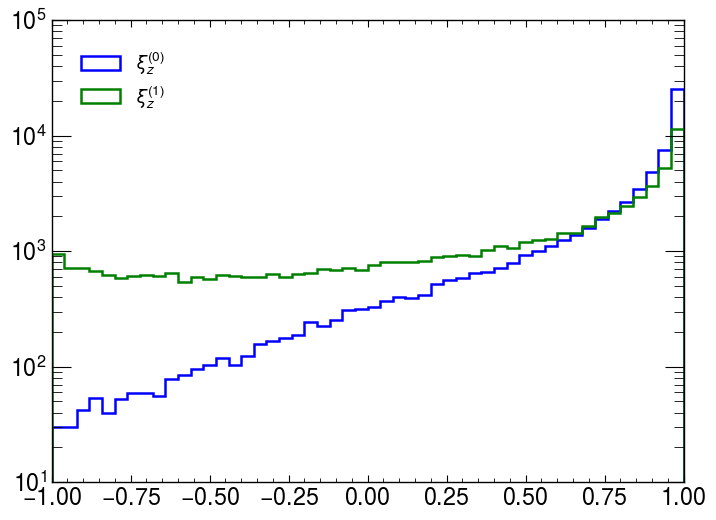

In [64]:
plt.hist(true_lab_xi0, bins=np.linspace(-1, 1, 51), histtype='step', color='blue', linewidth=1.8, label=r"$\xi^{(0)}_z$")
plt.hist(true_lab_xi1, bins=np.linspace(-1, 1, 51), histtype='step', color='green', linewidth=1.8, label=r"$\xi^{(1)}_z$")
plt.semilogy()
plt.legend()
plt.show()

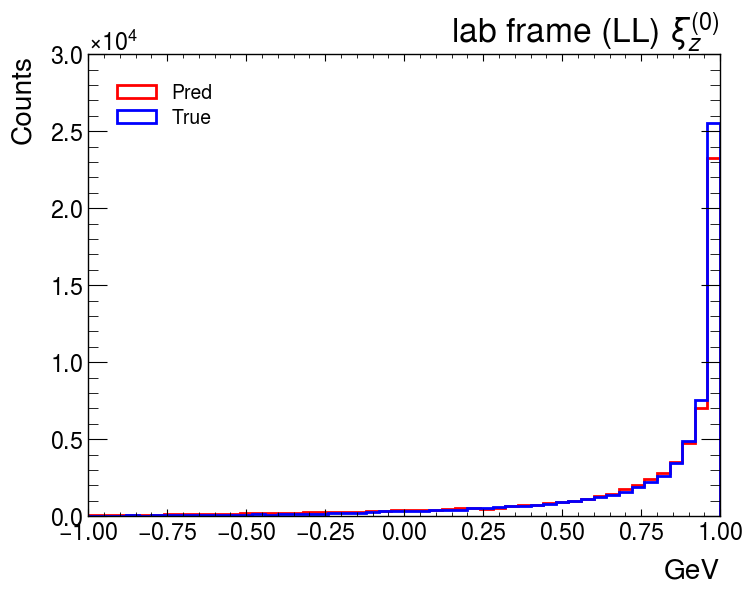

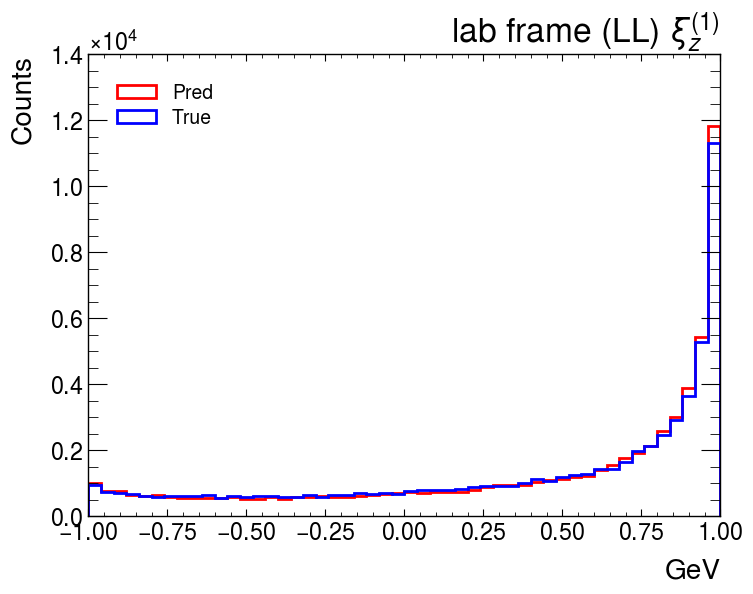

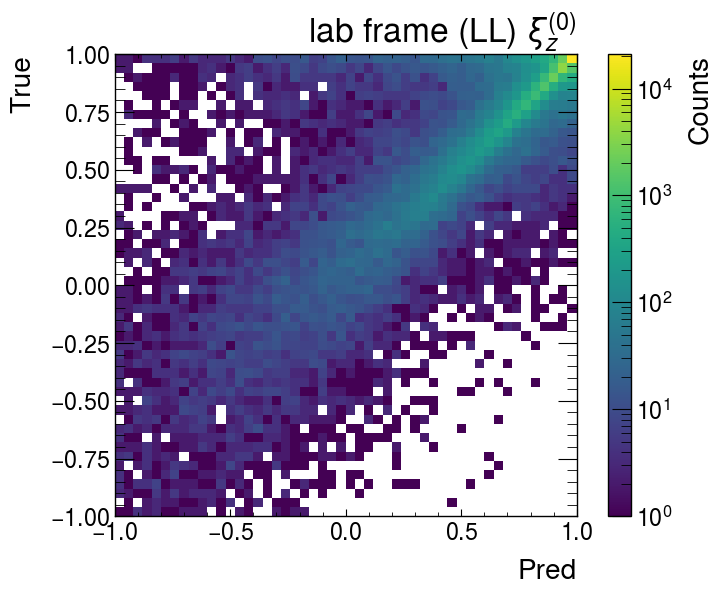

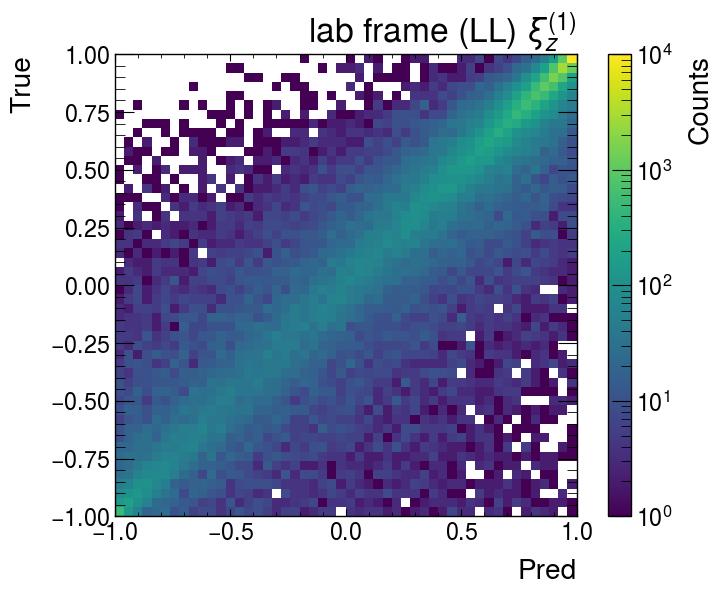

In [66]:
# LL plots
plot_1d_hist(pred_lab_xi0, true_lab_xi0, r"lab frame (LL) $\xi^{(0)}_z$", bins_edges=np.linspace(-1, 1, 51))
plot_1d_hist(pred_lab_xi1, true_lab_xi1, r"lab frame (LL) $\xi^{(1)}_z$", bins_edges=np.linspace(-1, 1, 51))
plot_2d_hist(pred_lab_xi0, true_lab_xi0, r"lab frame (LL) $\xi^{(0)}_z$", bins_edges=np.linspace(-1, 1, 51), log=True)
plot_2d_hist(pred_lab_xi1, true_lab_xi1, r"lab frame (LL) $\xi^{(1)}_z$", bins_edges=np.linspace(-1, 1, 51), log=True)

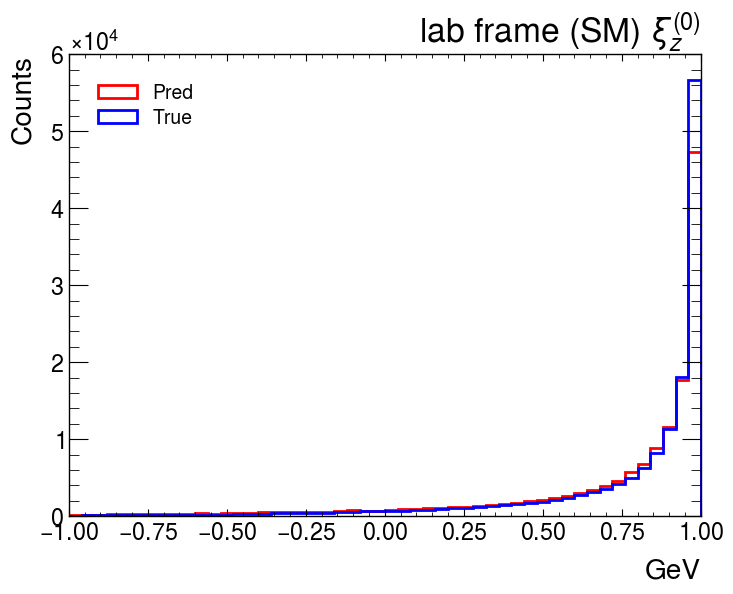

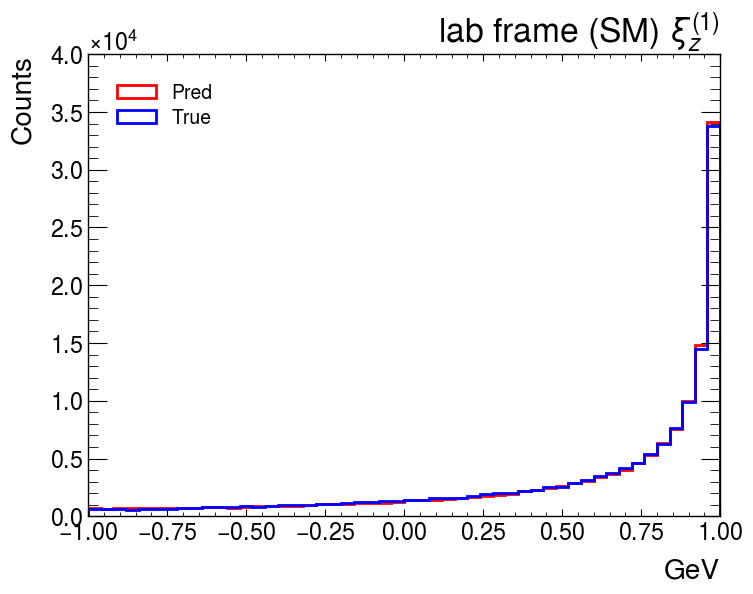

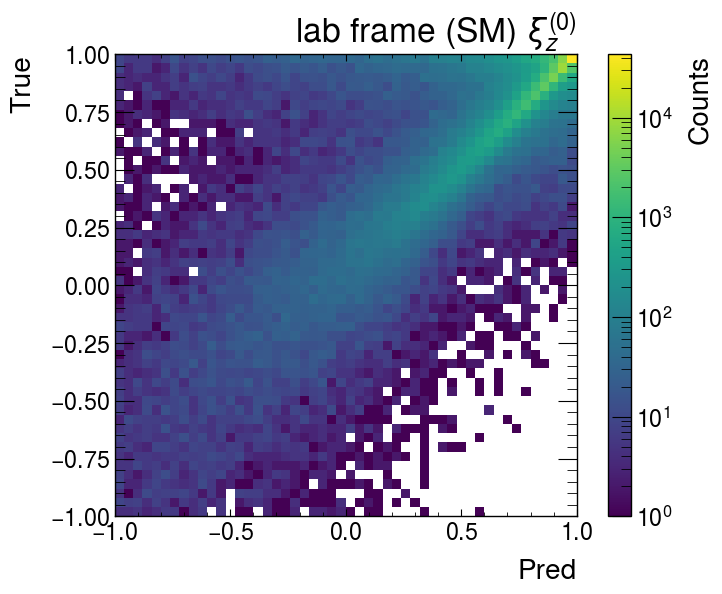

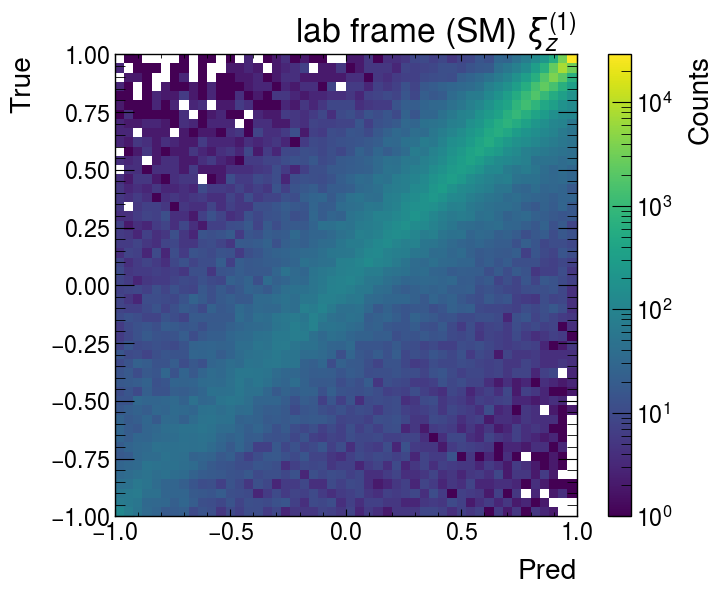

In [67]:
# sm plots
plot_1d_hist(sm_pred_lab_xi0, sm_true_lab_xi0, r"lab frame (SM) $\xi^{(0)}_z$", bins_edges=np.linspace(-1, 1, 51))
plot_1d_hist(sm_pred_lab_xi1, sm_true_lab_xi1, r"lab frame (SM) $\xi^{(1)}_z$", bins_edges=np.linspace(-1, 1, 51))
plot_2d_hist(sm_pred_lab_xi0, sm_true_lab_xi0, r"lab frame (SM) $\xi^{(0)}_z$", bins_edges=np.linspace(-1, 1, 51), log=True)
plot_2d_hist(sm_pred_lab_xi1, sm_true_lab_xi1, r"lab frame (SM) $\xi^{(1)}_z$", bins_edges=np.linspace(-1, 1, 51), log=True)

In [ ]:
#  ll true sample derivation 

import time
from ohbboosting import Booster
t1 = time.time()

true_w0_p4 = np.stack([true_w0_px, true_w0_py, true_w0_pz, true_w0_energy], axis=1)
true_l0_p4 = np.stack([train_features[:, 0], train_features[:, 1], train_features[:, 2], train_features[:, 3]], axis=1)
true_w1_p4 = np.stack([true_w1_px, true_w1_py, true_w1_pz, true_w1_energy], axis=1)
true_l1_p4 = np.stack([train_features[:, 4], train_features[:, 5], train_features[:, 6], train_features[:, 7]], axis=1)

particles = np.concatenate(
	[
		true_w0_p4[:50_000],
		true_l0_p4[:50_000],
		true_w1_p4[:50_000],
		true_l1_p4[:50_000],
	],
	axis=-1,
)
booster = Booster(particles)
booster.setup()
print(particles.shape)
true_l0_theta_phi, true_l1_theta_phi = booster.lep_theta_phi_in_w_rest()
true_xi_pos, true_xi_neg = booster.lep_xi_in_w_rest()
true_cglmp_bij = booster.cglmp_bij()
t2 = time.time()
print(f"Elapsed time: {t2 - t1:<.2f} seconds")

(50000, 16)
Elapsed time: 0.49 seconds


In [ ]:
# ll predicted sample derivation

t1 = time.time()
pred_w0_p4 = np.stack([pred_w0_px, pred_w0_py, pred_w0_pz, pred_w0_energy], axis=1)
pred_w1_p4 = np.stack([pred_w1_px, pred_w1_py, pred_w1_pz, pred_w1_energy], axis=1)

particles = np.concatenate(
	[
		pred_w0_p4[:50_000],
		true_l0_p4[:50_000], # we can measure lepton 4-momentum precisely
		pred_w1_p4[:50_000],
		true_l1_p4[:50_000],
	],
	axis=-1,
)
booster = Booster(particles)
booster.setup()
print(particles.shape)
pred_l0_theta_phi, pred_l1_theta_phi = booster.lep_theta_phi_in_w_rest()
pred_xi_pos, pred_xi_neg = booster.lep_xi_in_w_rest()
pred_cglmp_bij = booster.cglmp_bij()
t2 = time.time()
print(f"Elapsed time: {t2 - t1:<.2f} seconds")

(50000, 16)
Elapsed time: 0.49 seconds


In [ ]:
# SM true sample derivation

t1 = time.time()

sm_true_w0_p4 = np.stack([sm_true_w0_px, sm_true_w0_py, sm_true_w0_pz, sm_true_w0_energy], axis=1)
sm_true_l0_p4 = np.stack([sm_train_features[:, 0], sm_train_features[:, 1], sm_train_features[:, 2], sm_train_features[:, 3]], axis=1)
sm_true_w1_p4 = np.stack([sm_true_w1_px, sm_true_w1_py, sm_true_w1_pz, sm_true_w1_energy], axis=1)
sm_true_l1_p4 = np.stack([sm_train_features[:, 4], sm_train_features[:, 5], sm_train_features[:, 6], sm_train_features[:, 7]], axis=1)

particles = np.concatenate(
	[
		sm_true_w0_p4[:50_000],
		sm_true_l0_p4[:50_000],
		sm_true_w1_p4[:50_000],
		sm_true_l1_p4[:50_000],
	],
	axis=-1,
)
booster = Booster(particles)
booster.setup()
print(particles.shape)
sm_true_l0_theta_phi, sm_true_l1_theta_phi = booster.lep_theta_phi_in_w_rest()
sm_true_xi_pos, sm_true_xi_neg = booster.lep_xi_in_w_rest()
sm_true_cglmp_bij = booster.cglmp_bij()
t2 = time.time()
print(f"Elapsed time: {t2 - t1:<.2f} seconds")

(50000, 16)
Elapsed time: 0.60 seconds


In [ ]:
# SM predicted sample derivation

t1 = time.time()

sm_pred_w0_p4 = np.stack([sm_pred_w0_px, sm_pred_w0_py, sm_pred_w0_pz, sm_pred_w0_energy], axis=1)
sm_pred_w1_p4 = np.stack([sm_pred_w1_px, sm_pred_w1_py, sm_pred_w1_pz, sm_pred_w1_energy], axis=1)

particles = np.concatenate(
	[
		sm_pred_w0_p4[:50_000],
		sm_true_l0_p4[:50_000], # we can measure lepton 4-momentum precisely
		sm_pred_w1_p4[:50_000],
		sm_true_l1_p4[:50_000],
	],
	axis=-1,
)
booster = Booster(particles)
booster.setup()
print(particles.shape)
sm_pred_l0_theta_phi, sm_pred_l1_theta_phi = booster.lep_theta_phi_in_w_rest()
sm_pred_xi_pos, sm_pred_xi_neg = booster.lep_xi_in_w_rest()
sm_pred_cglmp_bij = booster.cglmp_bij()
t2 = time.time()
print(f"Elapsed time: {t2 - t1:<.2f} seconds")

(50000, 16)
Elapsed time: 0.48 seconds


In [ ]:
def plot_1d_comparison(LL, SM, truth_LL, truth_SM, name, bins_edges=np.linspace(-200, 200, 51), units=""):
	plt.figure(figsize=(6, 4))
	plt.hist(LL, bins=bins_edges, linewidth=2, color="orangered", histtype="step", label="Pred LL", density=True)
	plt.hist(SM, bins=bins_edges, linewidth=2, color="blue", histtype="step", label="Pred SM", density=True)
	plt.hist(truth_LL, bins=bins_edges, histtype="bar", alpha=.6, color="tab:orange", label="True LL", density=True)
	plt.hist(truth_SM, bins=bins_edges, histtype="bar", alpha=.6, color="tab:blue", label="True SM", density=True)
	plt.legend(ncol=1)
	plt.xlabel(units, loc="right")
	plt.ylabel("Unit Norm", loc="top")
	plt.title(name, loc="right", size=16)
	plt.show()

In [ ]:
def plot_error(
    ll_pred,
    ll_true,
    sm_pred,
    sm_true,
    name="xi",
    units="",
    pred_range=None,
    nbins_x=51,
    nbins_y=51,
    err_percentile=96,
    rnd_sample=50_000,
    rel_eps=1e-8
):
    """Only plot relative error = (pred - true) / true. 2 panels: LL | SM. cmap='viridis'."""
    llp, llt = ll_pred, ll_true
    smp, smt = sm_pred, sm_true

    def sample(a):
        # return np.random.choice(a, size=rnd_sample, replace=False)
        return a[:rnd_sample] # be aware of the order of input arrays

    llp, llt, smp, smt = sample(llp), sample(llt), sample(smp), sample(smt)

    # safe relative error
    ll_true_safe = np.where(np.abs(llt) > rel_eps, llt, np.nan)
    sm_true_safe = np.where(np.abs(smt) > rel_eps, smt, np.nan)
    ll_diff = llp - llt
    sm_diff = smp - smt
    ll_rel = ll_diff / ll_true_safe
    sm_rel = sm_diff / sm_true_safe

    # RMSE
    def rmse(arr):
        m = np.isfinite(arr)
        return float(np.sqrt(np.mean(arr[m]**2))) if np.any(m) else np.nan

    ll_rel_rmse, sm_rel_rmse = rmse(ll_diff), rmse(sm_diff)

    # prediction axis
    if pred_range is not None:
        x_edges = np.linspace(pred_range[0], pred_range[1], nbins_x + 1)
    else:
        x_edges = np.linspace(np.nanmin(np.concatenate([llp, smp])), 
                            np.nanmax(np.concatenate([llp, smp])), nbins_x + 1)

    # relative residual axis (robust percentile)
    masks = (np.isfinite(ll_rel), np.isfinite(sm_rel))
    def pct_max(arr, mask):
        return np.percentile(np.abs(arr[mask]), err_percentile) if np.any(mask) else 0.0
    m_rel = float(np.nanmax([pct_max(ll_rel, masks[0]), pct_max(sm_rel, masks[1])]))
    if not np.isfinite(m_rel) or m_rel <= 0:
        m_rel = 1.0
    y_edges = np.linspace(-m_rel, m_rel, nbins_y + 1)

    # 1D relative distribution
    rel_edges = np.linspace(-m_rel, m_rel, 51)
    plt.figure(figsize=(6, 4))
    plt.hist(ll_rel, bins=rel_edges, histtype="step", label="LL rel", density=True, color="red", linewidth=2.0)
    plt.hist(sm_rel, bins=rel_edges, histtype="step", label="SM rel", density=True, color="blue", linewidth=2.0)
    plt.axvline(0, color="k", linestyle="--", linewidth=1)
    plt.xlabel("Relative error")
    plt.ylabel("Unit Norm")
    plt.title(f"{name} (relative)", loc="right")
    plt.legend()
    plt.show()

    # 2D relative residual vs prediction (shared LogNorm, viridis)
    H_ll, _, _ = np.histogram2d(llp, ll_rel, bins=[x_edges, y_edges])
    H_sm, _, _ = np.histogram2d(smp, sm_rel, bins=[x_edges, y_edges])
    H_max = float(max(H_ll.max(), H_sm.max(), 1.0))
    norm = LogNorm(vmin=1, vmax=H_max)

    centers = 0.5 * (x_edges[1:] + x_edges[:-1])
    fig = plt.figure(figsize=(10, 3.5))
    gs = fig.add_gridspec(1, 2, wspace=0.08)
    ax_ll = fig.add_subplot(gs[0, 0])
    ax_sm = fig.add_subplot(gs[0, 1], sharey=ax_ll)
    ax_sm.tick_params(labelleft=False)

    ax_ll.hist2d(llp, ll_rel, bins=[x_edges, y_edges], norm=norm, cmin=1, cmap="viridis")
    ax_ll.axhline(0, color="w", linestyle="--", linewidth=1)
    idx = np.digitize(llp, x_edges) - 1
    means = np.array([np.nanmean(ll_rel[idx == i]) if np.any(idx == i) else np.nan for i in range(len(centers))])
    ax_ll.plot(centers, means, color="lightgrey", linewidth=1.8)
    ax_ll.set_xlabel(f"LL {name} pred {units}".strip())
    ax_ll.set_ylabel("Relative error")
    ax_ll.set_title(f"RMSE={ll_rel_rmse:.4f}", loc="right")

    ax_sm.hist2d(smp, sm_rel, bins=[x_edges, y_edges], norm=norm, cmin=1, cmap="viridis")
    ax_sm.axhline(0, color="w", linestyle="--", linewidth=1)
    idx = np.digitize(smp, x_edges) - 1
    means = np.array([np.nanmean(sm_rel[idx == i]) if np.any(idx == i) else np.nan for i in range(len(centers))])
    ax_sm.plot(centers, means, color="lightgrey", linewidth=1.8)
    ax_sm.set_xlabel(f"SM {name} pred {units}".strip())
    ax_sm.set_title(f"RMSE={sm_rel_rmse:.4f}", loc="right")

    plt.show()

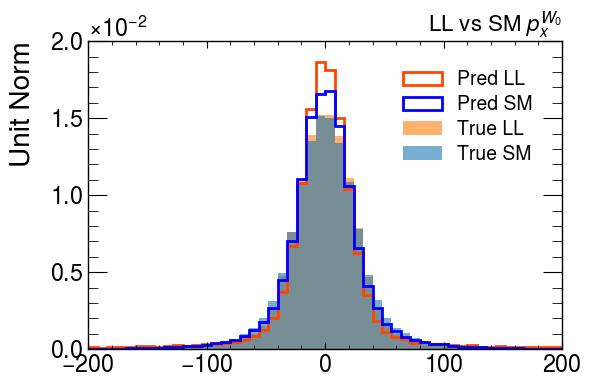

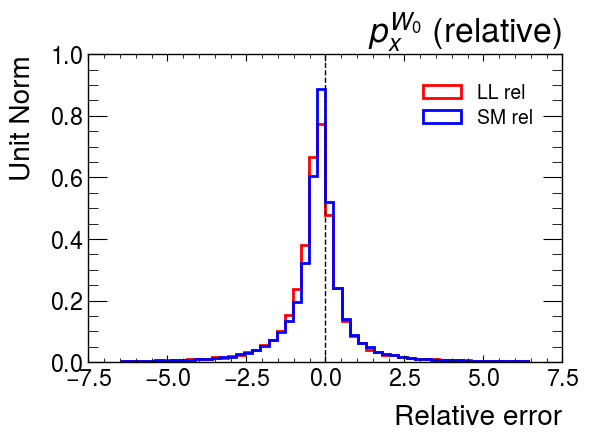

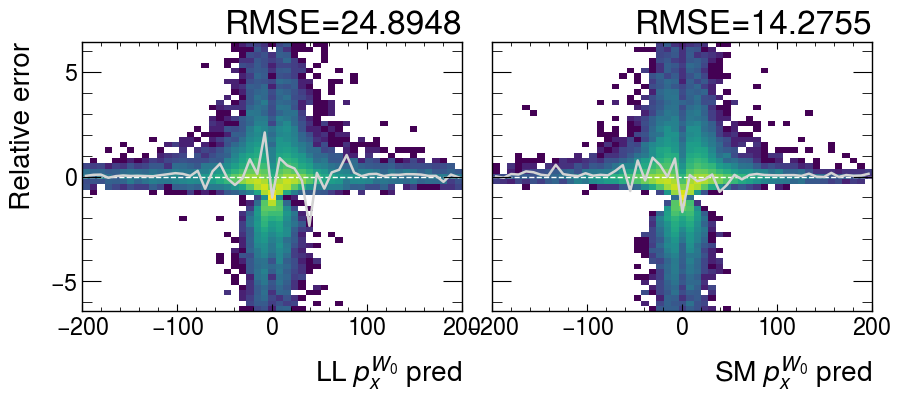

In [ ]:
plot_1d_comparison(pred_w0_px, sm_pred_w0_px, true_w0_px, sm_true_w0_px, "LL vs SM "+r"$p_x^{W_0}$", np.linspace(-200, 200, 51))
plot_error(
    ll_pred=pred_w0_px,
    ll_true=true_w0_px,
    sm_pred=sm_pred_w0_px,
    sm_true=sm_true_w0_px,
    name=r"$p_x^{W_0}$",
    units="",
    pred_range=(-200, 200),
    # residual_y_range=(-200, 200), 
)

In [ ]:
def rmse(arr):
	m = np.isfinite(arr)
	return float(np.sqrt(np.mean(arr[m]**2))) if np.any(m) else np.nan
print("LL xi pos RMSE:", rmse(pred_w1_px - true_w1_px))

LL xi pos RMSE: 25.181001999964835


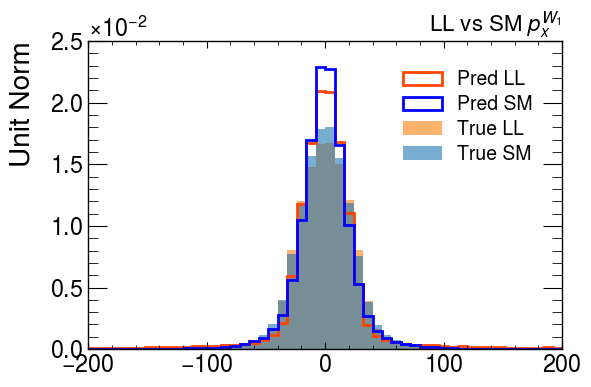

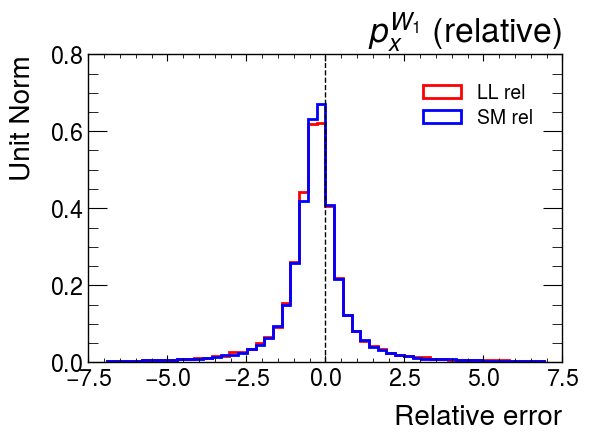

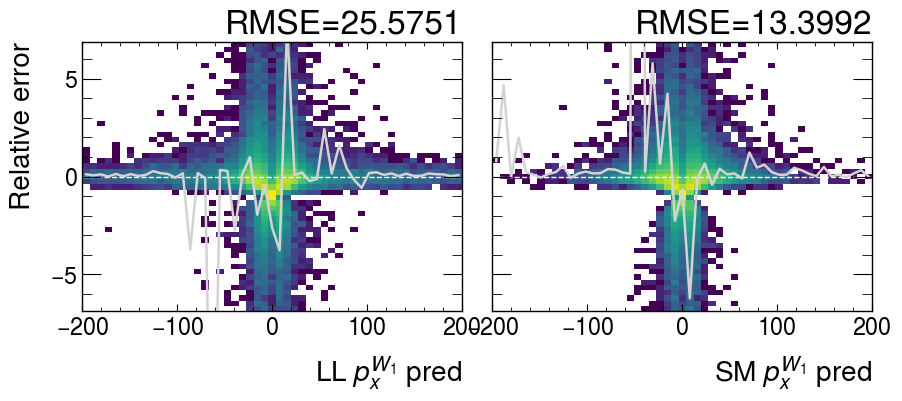

In [ ]:
plot_1d_comparison(pred_w1_px, sm_pred_w1_px, true_w1_px, sm_true_w1_px, "LL vs SM "+r"$p_x^{W_1}$", np.linspace(-200, 200, 51))
plot_error(
    ll_pred=pred_w1_px,
    ll_true=true_w1_px,
    sm_pred=sm_pred_w1_px,
    sm_true=sm_true_w1_px,
    name=r"$p_x^{W_1}$",
    units="",
    pred_range=(-200, 200),
    # residual_y_range=(-200, 200), 
)

In [ ]:
arr = np.random.rand(100_000)
print(arr.shape)
arr_choice = np.random.choice(arr, size=1000, replace=False)
print("Random arr choice RMSE:", rmse(arr_choice))
print("Random arr RMSE:", rmse(arr[:1000]))

(100000,)
Random arr choice RMSE: 0.5725310175391788
Random arr RMSE: 0.5810744551461146


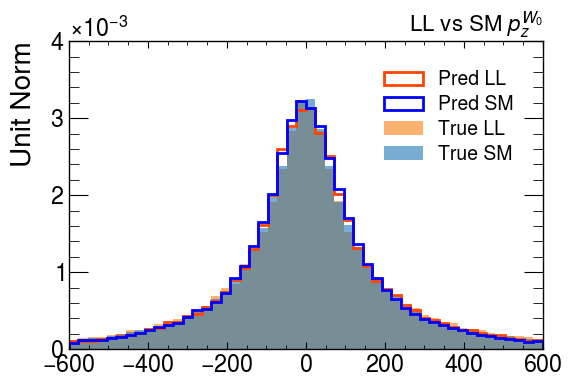

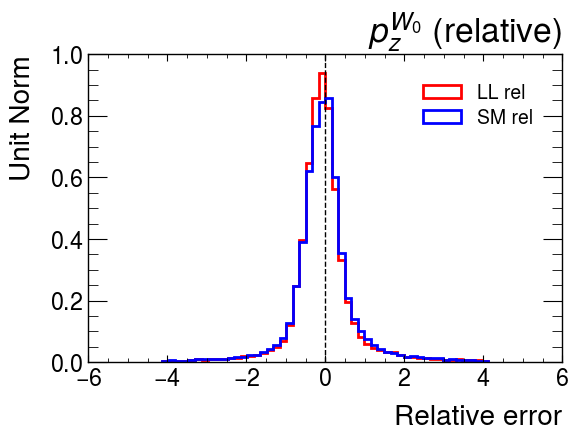

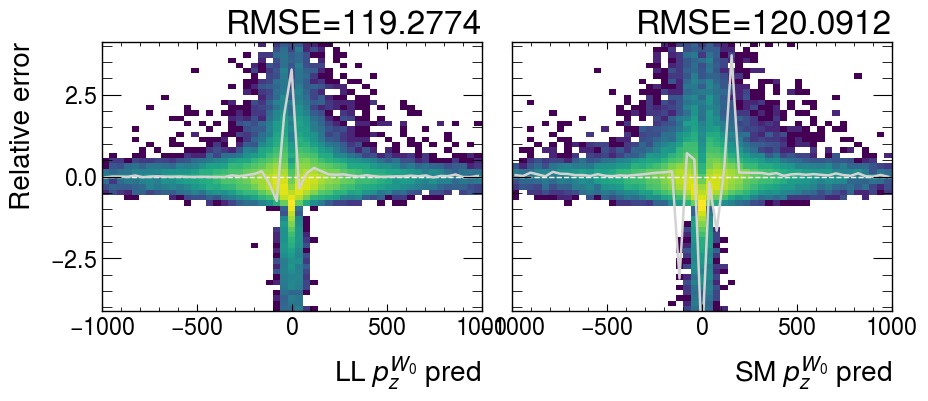

In [ ]:
plot_1d_comparison(pred_w0_pz, sm_pred_w0_pz, true_w0_pz, sm_true_w0_pz, "LL vs SM "+r"$p_z^{W_0}$", np.linspace(-600, 600, 51))
plot_error(
    ll_pred=pred_w0_pz,
    ll_true=true_w0_pz,
    sm_pred=sm_pred_w0_pz,
    sm_true=sm_true_w0_pz,
    name=r"$p_z^{W_0}$",
    units="",
    pred_range=(-1000, 1000),
    # residual_y_range=(-1000, 1000),
)

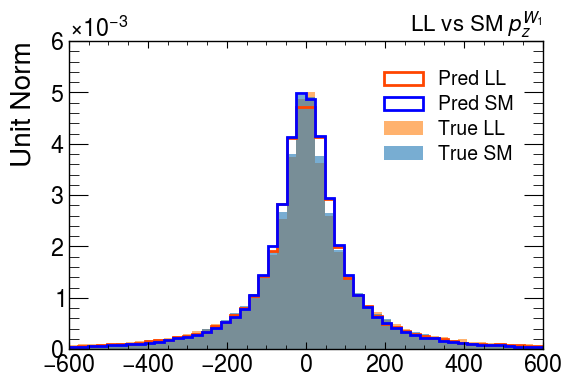

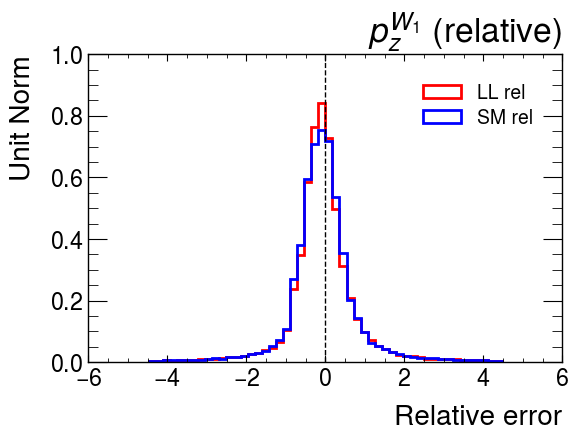

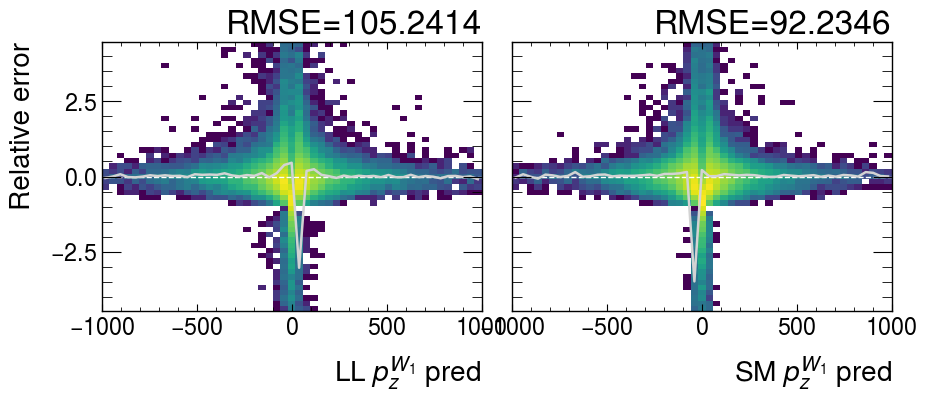

In [ ]:
plot_1d_comparison(pred_w1_pz, sm_pred_w1_pz, true_w1_pz, sm_true_w1_pz, "LL vs SM "+r"$p_z^{W_1}$", np.linspace(-600, 600, 51))
plot_error(
    ll_pred=pred_w1_pz,
    ll_true=true_w1_pz,
    sm_pred=sm_pred_w1_pz,
    sm_true=sm_true_w1_pz,
    name=r"$p_z^{W_1}$",
    units="",
    pred_range=(-1000, 1000),
    # residual_y_range=(-1000, 1000),
)

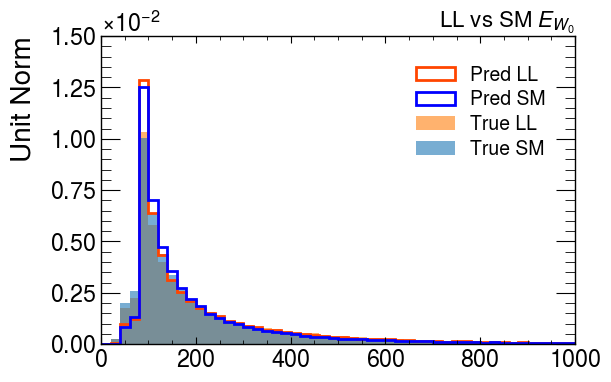

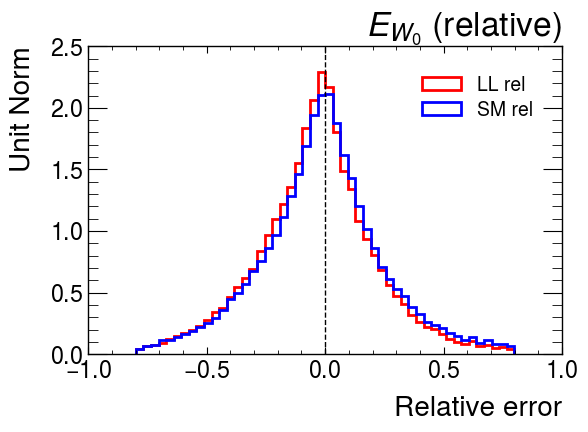

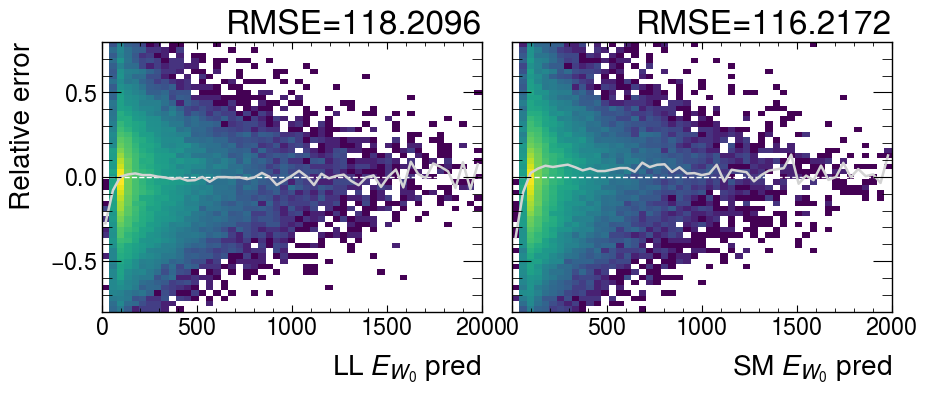

In [ ]:
plot_1d_comparison(pred_w0_energy, sm_pred_w0_energy, true_w0_energy, sm_true_w0_energy, "LL vs SM "+r"$E_{W_0}$", np.linspace(0, 1000, 51))
plot_error(
    ll_pred=pred_w0_energy,
    ll_true=true_w0_energy,
    sm_pred=sm_pred_w0_energy,
    sm_true=sm_true_w0_energy,
    name=r"$E_{W_0}$",
    units="",
    pred_range=(0, 2000),
    # residual_y_range=(-4000, 2000),
)

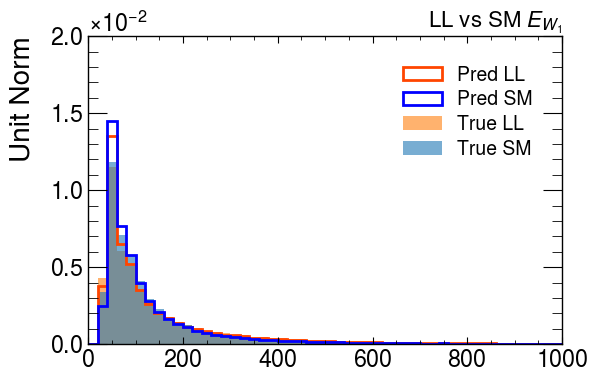

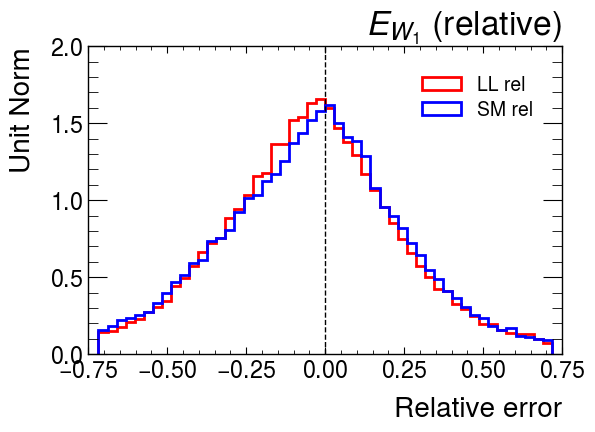

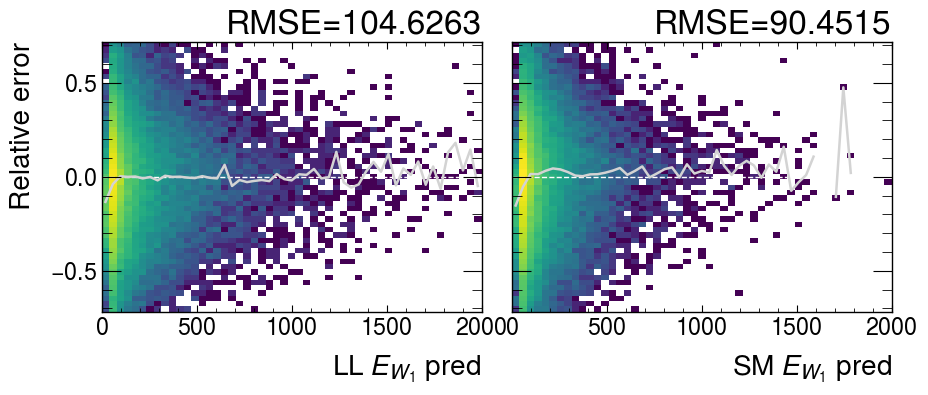

In [ ]:
plot_1d_comparison(pred_w1_energy, sm_pred_w1_energy, true_w1_energy, sm_true_w1_energy, "LL vs SM "+r"$E_{W_1}$", np.linspace(0, 1000, 51))
plot_error(
    ll_pred=pred_w1_energy,
    ll_true=true_w1_energy,
    sm_pred=sm_pred_w1_energy,
    sm_true=sm_true_w1_energy,
    name=r"$E_{W_1}$",
    units="",
    pred_range=(0, 2000),
    # residual_y_range=(-4000, 2000),
)

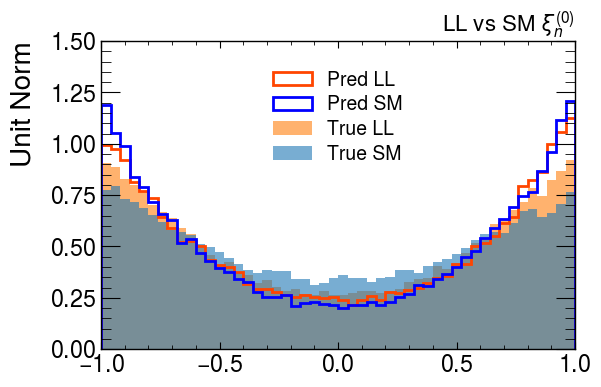

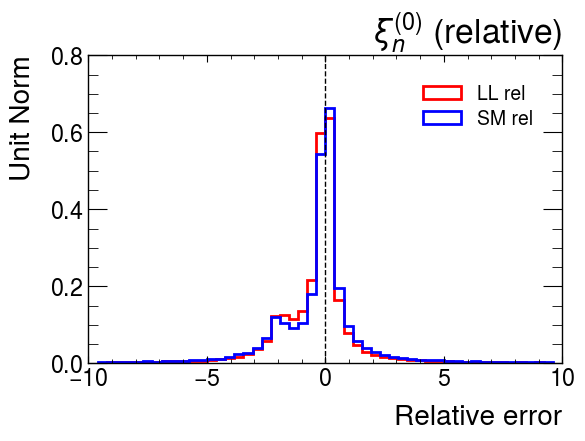

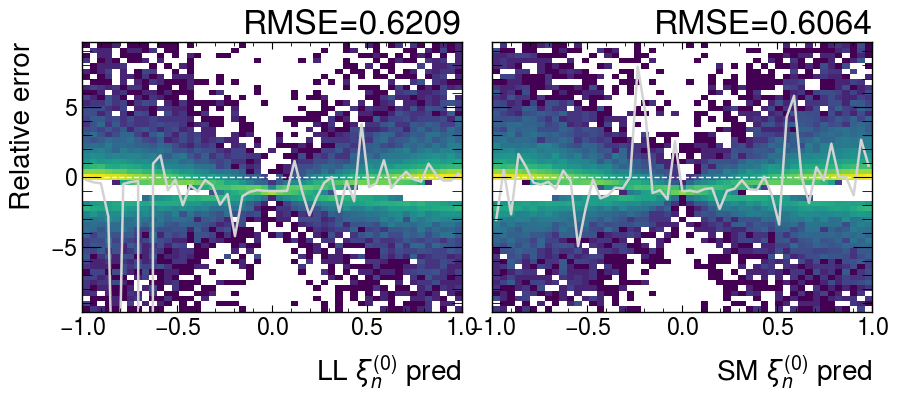

In [ ]:
plot_1d_comparison(pred_xi_pos[0], sm_pred_xi_pos[0], true_xi_pos[0], sm_true_xi_pos[0], "LL vs SM "+r"$\xi^{(0)}_n$", np.linspace(-1, 1, 51))
plot_error(
    ll_pred=pred_xi_pos[0],
    ll_true=true_xi_pos[0],
    sm_pred=sm_pred_xi_pos[0],
    sm_true=sm_true_xi_pos[0],
    name=r"$\xi^{(0)}_n$",
    units="",
    pred_range=(-1, 1),
    # residual_y_range=(-2, 2),
)

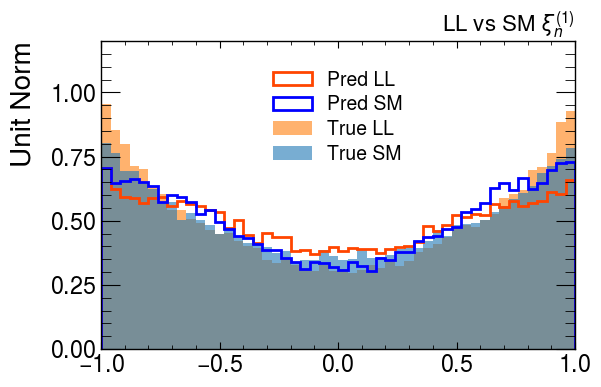

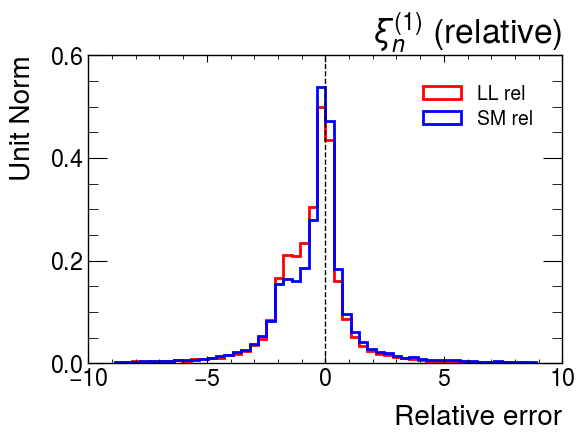

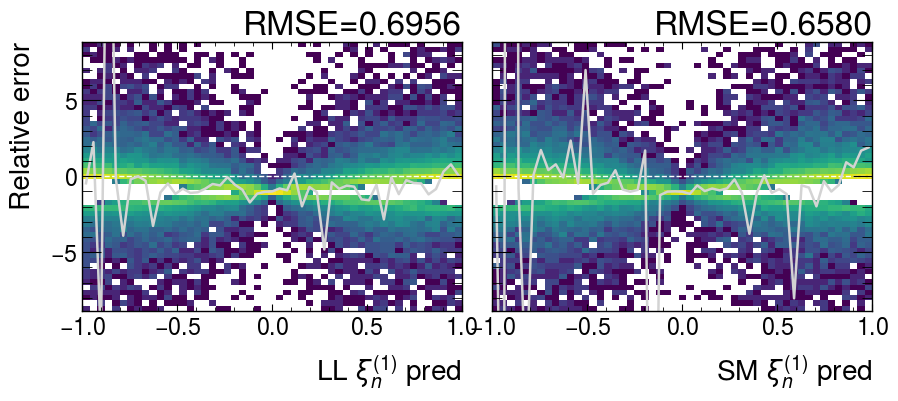

In [ ]:
plot_1d_comparison(pred_xi_neg[0], sm_pred_xi_neg[0], true_xi_neg[0], sm_true_xi_neg[0], "LL vs SM "+r"$\xi^{(1)}_n$", np.linspace(-1, 1, 51))
plot_error(
    ll_pred=pred_xi_neg[0],
    ll_true=true_xi_neg[0],
    sm_pred=sm_pred_xi_neg[0],
    sm_true=sm_true_xi_neg[0],
    name=r"$\xi^{(1)}_n$",
    units="",
    pred_range=(-1, 1),
    # residual_y_range=(-2, 2),
)

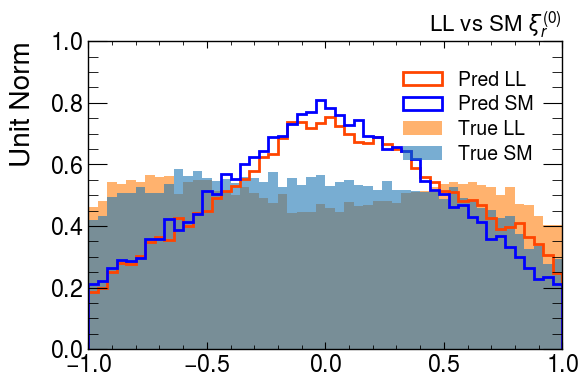

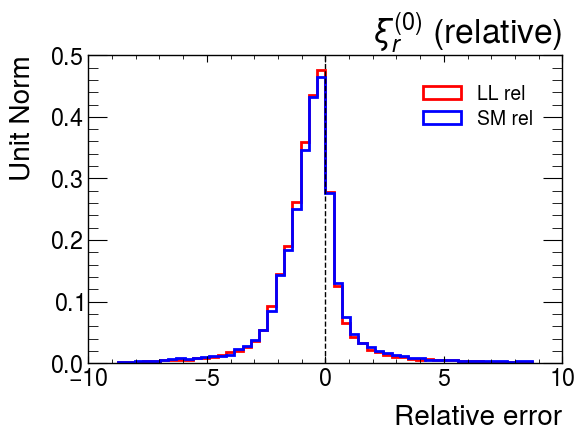

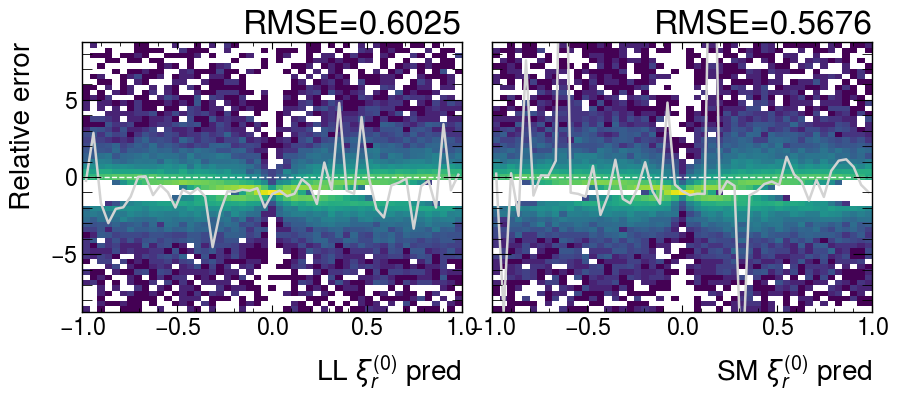

In [ ]:
plot_1d_comparison(pred_xi_pos[1], sm_pred_xi_pos[1], true_xi_pos[1], sm_true_xi_pos[1], "LL vs SM "+r"$\xi^{(0)}_r$", np.linspace(-1, 1, 51))
plot_error(
    ll_pred=pred_xi_pos[1],
    ll_true=true_xi_pos[1],
    sm_pred=sm_pred_xi_pos[1],
    sm_true=sm_true_xi_pos[1],
    name=r"$\xi^{(0)}_r$",
    units="",
    pred_range=(-1, 1),
    # residual_y_range=(-2, 2),
)

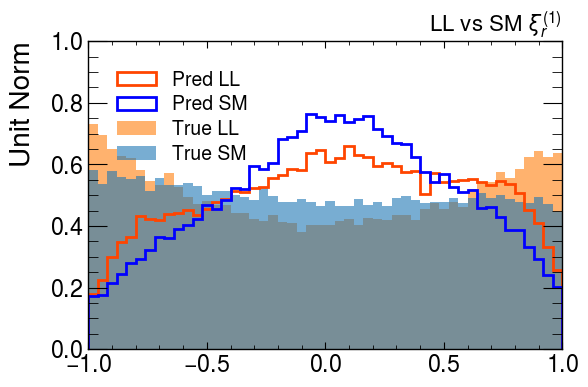

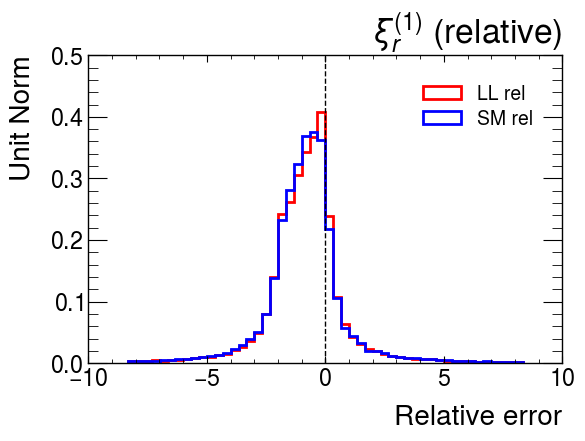

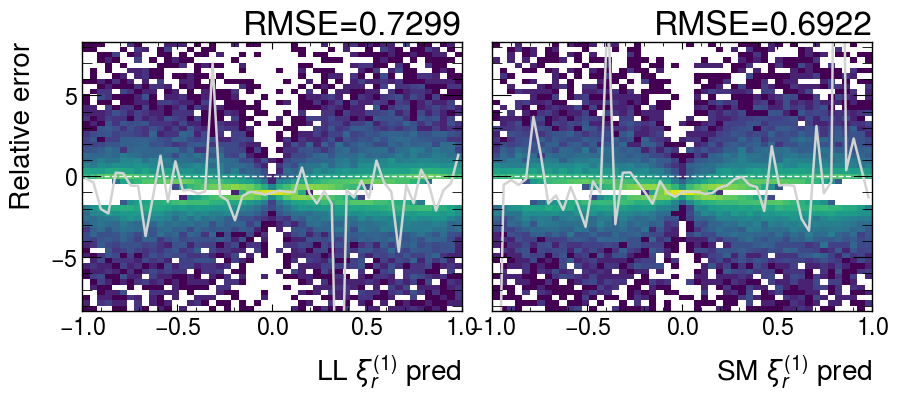

In [ ]:
plot_1d_comparison(pred_xi_neg[1], sm_pred_xi_neg[1], true_xi_neg[1], sm_true_xi_neg[1], "LL vs SM "+r"$\xi^{(1)}_r$", np.linspace(-1, 1, 51))
plot_error(
    ll_pred=pred_xi_neg[1],
    ll_true=true_xi_neg[1],
    sm_pred=sm_pred_xi_neg[1],
    sm_true=sm_true_xi_neg[1],
    name=r"$\xi^{(1)}_r$",
    units="",
    pred_range=(-1, 1),
    # residual_y_range=(-2, 2),
)

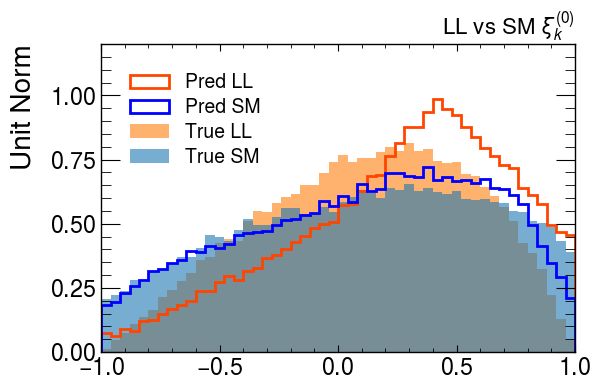

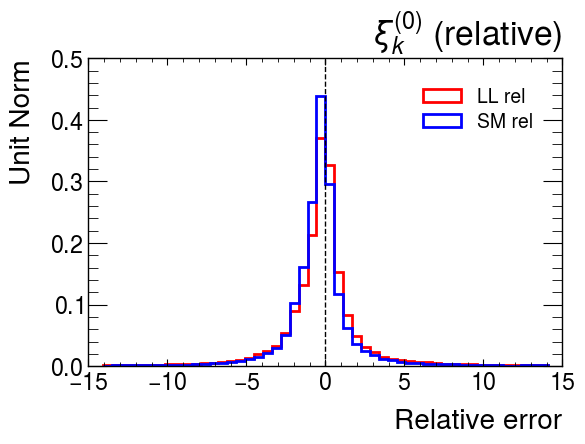

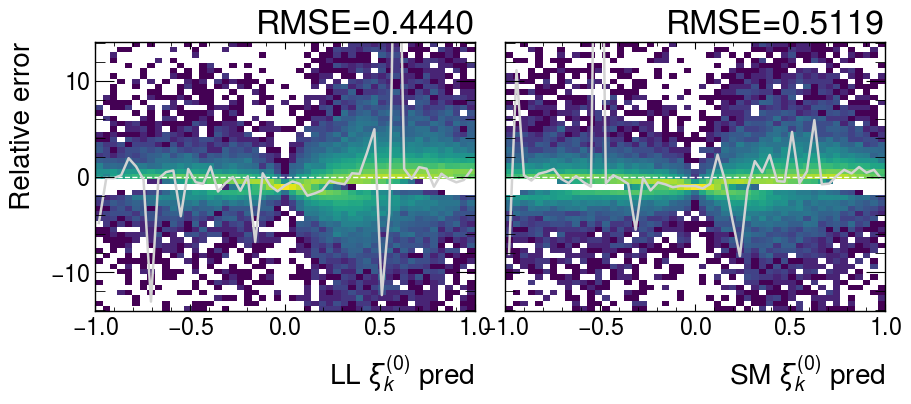

In [ ]:
plot_1d_comparison(pred_xi_pos[2], sm_pred_xi_pos[2], true_xi_pos[2], sm_true_xi_pos[2], "LL vs SM "+r"$\xi^{(0)}_k$", np.linspace(-1, 1, 51))
plot_error(
    ll_pred=pred_xi_pos[2],
    ll_true=true_xi_pos[2],
    sm_pred=sm_pred_xi_pos[2],
    sm_true=sm_true_xi_pos[2],
    name=r"$\xi^{(0)}_k$",
    units="",
    pred_range=(-1, 1),
    # residual_y_range=(-2, 2),
)

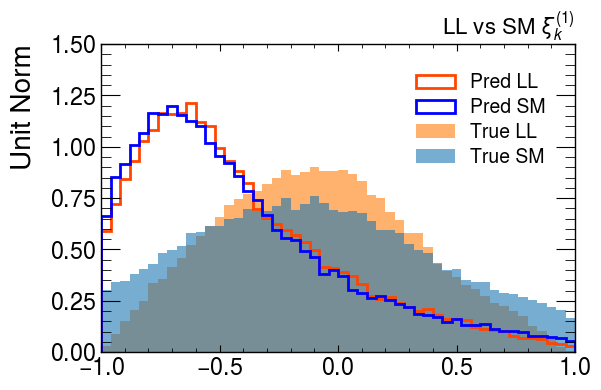

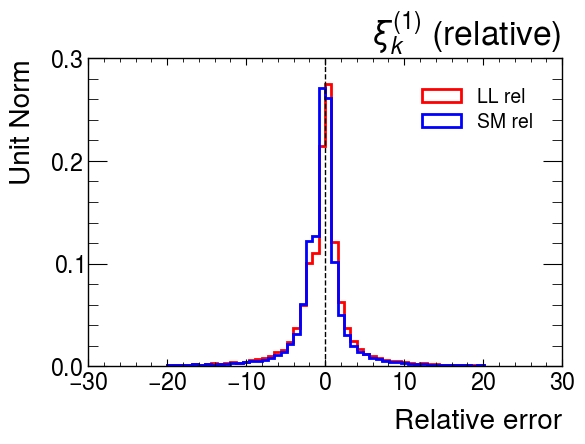

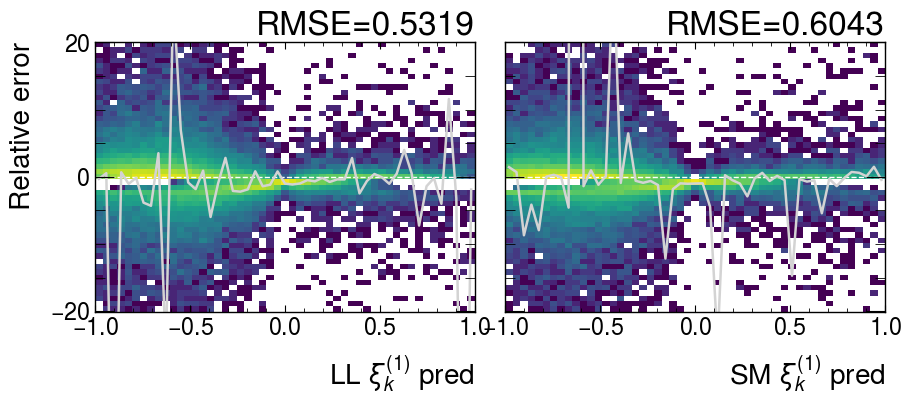

In [ ]:
plot_1d_comparison(pred_xi_neg[2], sm_pred_xi_neg[2], true_xi_neg[2], sm_true_xi_neg[2], "LL vs SM "+r"$\xi^{(1)}_k$", np.linspace(-1, 1, 51))
plot_error(
    ll_pred=pred_xi_neg[2],
    ll_true=true_xi_neg[2],
    sm_pred=sm_pred_xi_neg[2],
    sm_true=sm_true_xi_neg[2],
    name=r"$\xi^{(1)}_k$",
    units="",
    pred_range=(-1, 1),
    # residual_y_range=(-2, 2),
)

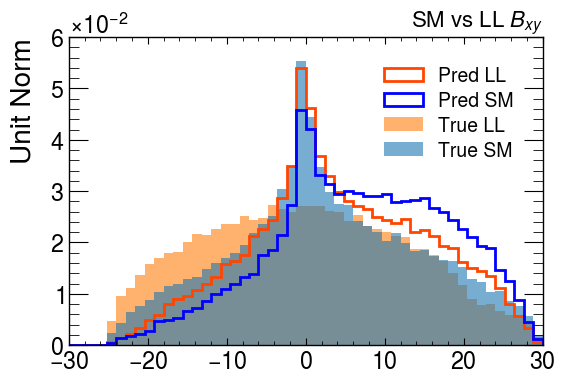

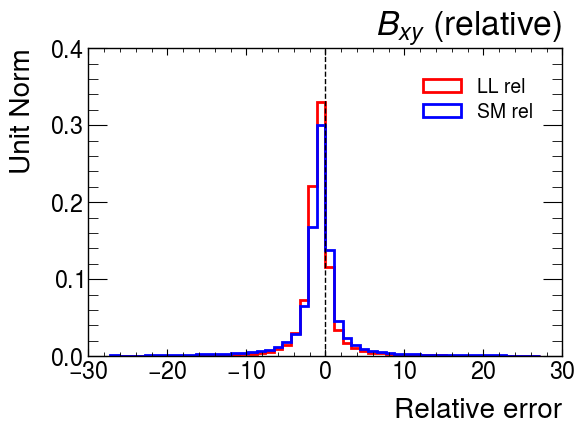

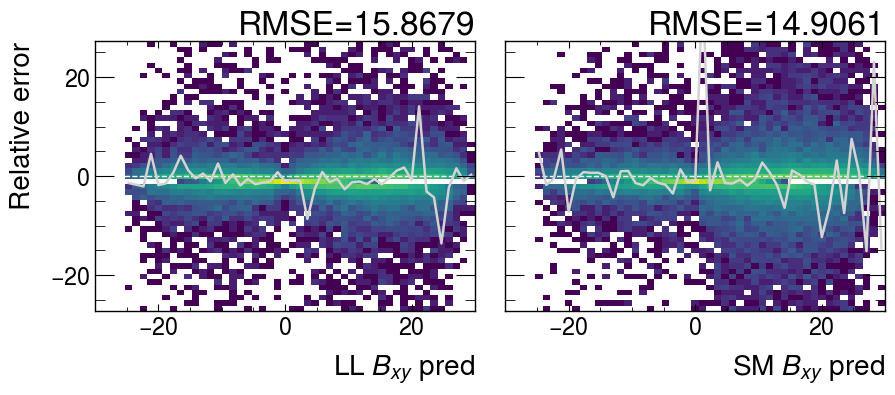

In [ ]:
plot_1d_comparison(pred_cglmp_bij[0], sm_pred_cglmp_bij[0], true_cglmp_bij[0], sm_true_cglmp_bij[0], "SM vs LL "+r"$B_{xy}$", np.linspace(-30, 30, 51))
plot_error(
    ll_pred=pred_cglmp_bij[0],
    ll_true=true_cglmp_bij[0],
    sm_pred=sm_pred_cglmp_bij[0],
    sm_true=sm_true_cglmp_bij[0],
    name=r"$B_{xy}$",
    units="",
    pred_range=(-30, 30),
    # residual_y_range=(-60, 60),
)

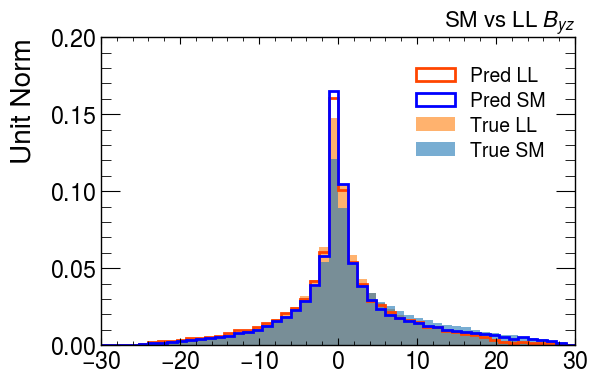

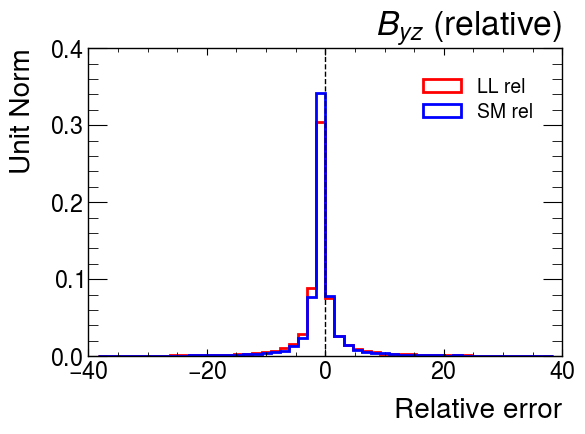

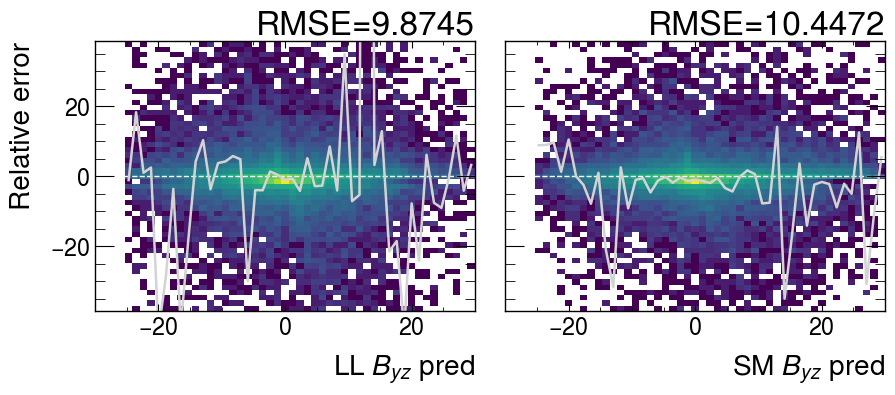

In [ ]:
plot_1d_comparison(pred_cglmp_bij[1], sm_pred_cglmp_bij[1], true_cglmp_bij[1], sm_true_cglmp_bij[1], "SM vs LL "+r"$B_{yz}$", np.linspace(-30, 30, 51))
plot_error(
    ll_pred=pred_cglmp_bij[1],
    ll_true=true_cglmp_bij[1],
    sm_pred=sm_pred_cglmp_bij[1],
    sm_true=sm_true_cglmp_bij[1],
    name=r"$B_{yz}$",
    units="",
    pred_range=(-30, 30),
    # residual_y_range=(-60, 60),
)

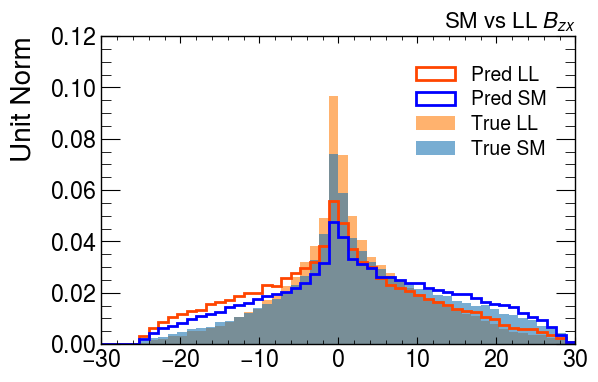

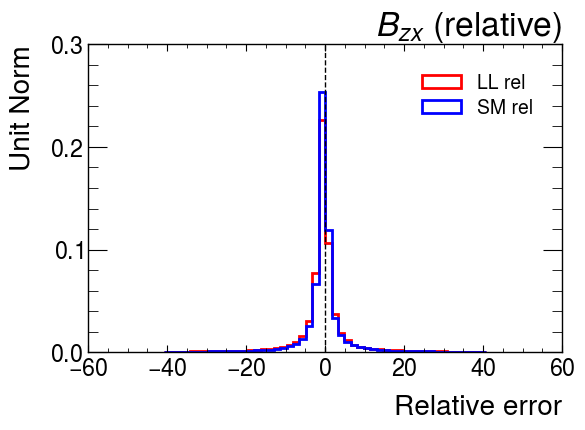

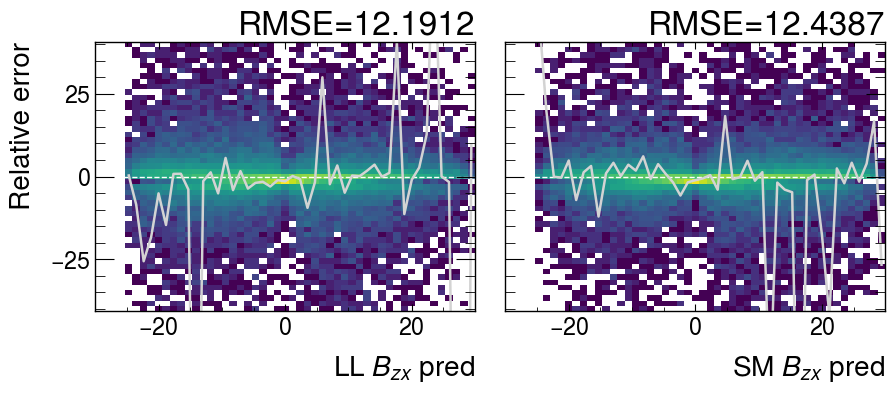

In [ ]:
plot_1d_comparison(pred_cglmp_bij[2], sm_pred_cglmp_bij[2], true_cglmp_bij[2], sm_true_cglmp_bij[2], "SM vs LL "+r"$B_{zx}$", np.linspace(-30, 30, 51))
plot_error(
    ll_pred=pred_cglmp_bij[2],
    ll_true=true_cglmp_bij[2],
    sm_pred=sm_pred_cglmp_bij[2],
    sm_true=sm_true_cglmp_bij[2],
    name=r"$B_{zx}$",
    units="",
    pred_range=(-30, 30),
    # residual_y_range=(-60, 60),
)

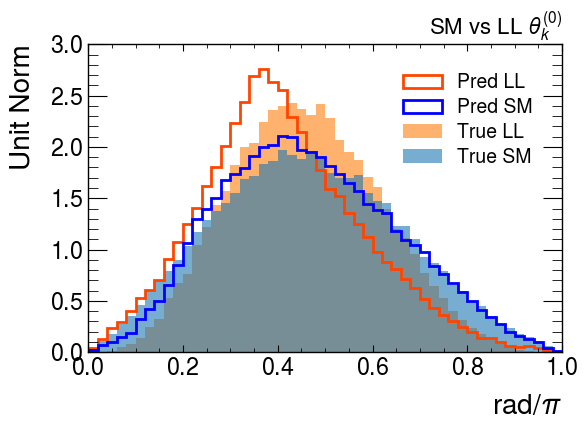

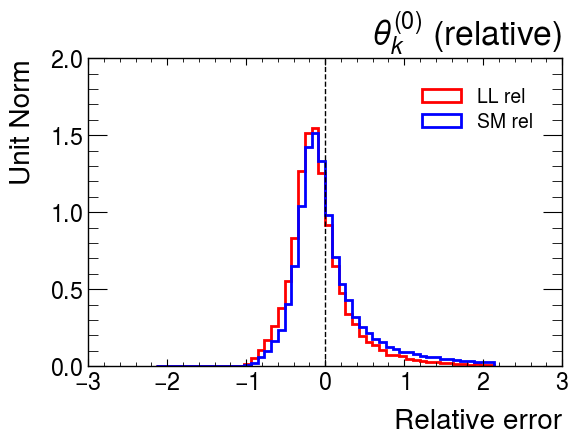

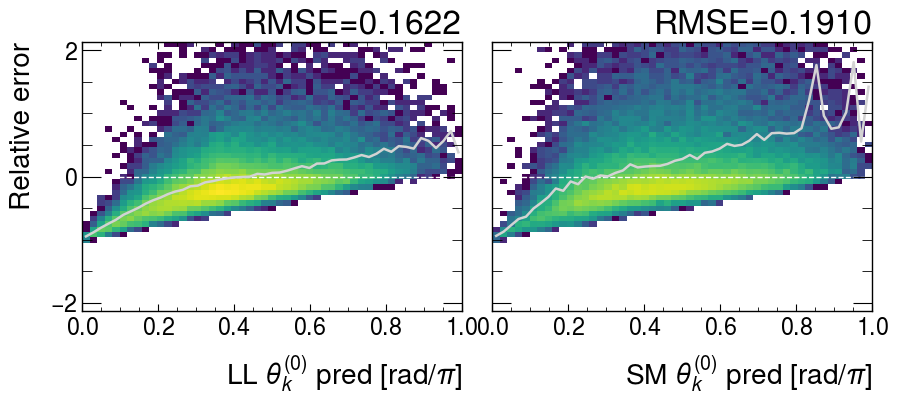

In [ ]:
plot_1d_comparison(pred_l0_theta_phi[0], sm_pred_l0_theta_phi[0], true_l0_theta_phi[0], sm_true_l0_theta_phi[0], "SM vs LL "+r"$\theta^{(0)}_k$", np.linspace(0, 1, 51), r"rad/$\pi$")
plot_error(
    ll_pred=pred_l0_theta_phi[0],
    ll_true=true_l0_theta_phi[0],
    sm_pred=sm_pred_l0_theta_phi[0],
    sm_true=sm_true_l0_theta_phi[0],
    name=r"$\theta^{(0)}_k$",
    units=r"[rad/$\pi$]",
    pred_range=(0, 1),
    # residual_y_range=(-1, 1),
)


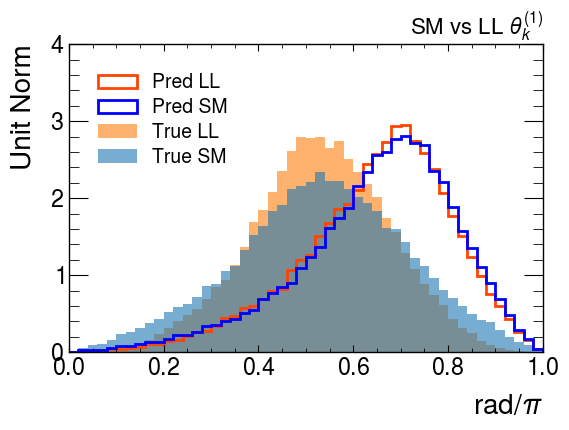

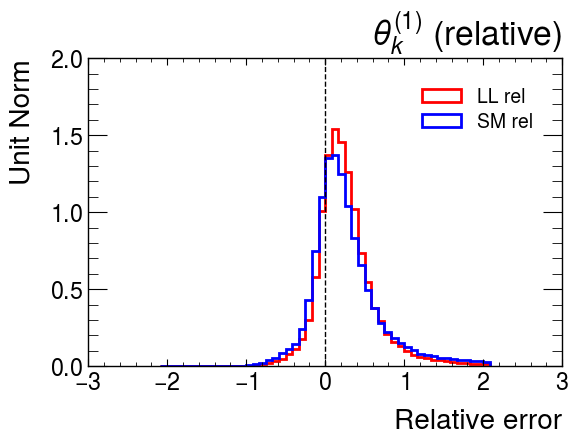

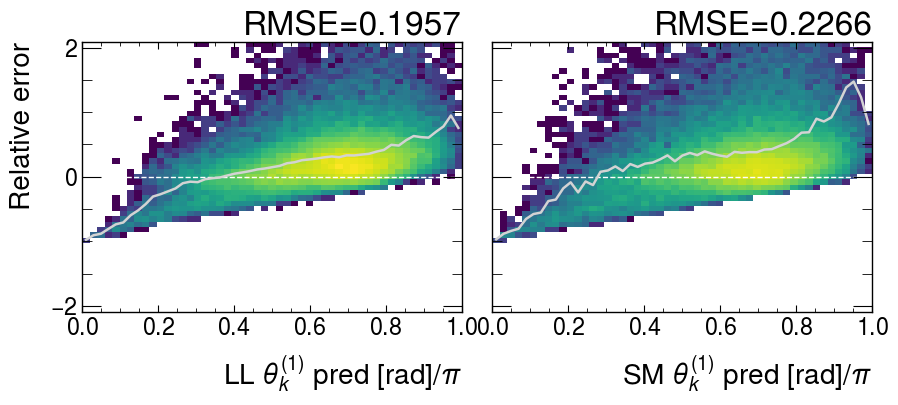

In [ ]:
plot_1d_comparison(pred_l1_theta_phi[0], sm_pred_l1_theta_phi[0], true_l1_theta_phi[0], sm_true_l1_theta_phi[0], "SM vs LL "+r"$\theta^{(1)}_k$", np.linspace(0, 1, 51), r"rad/$\pi$")
plot_error(
    ll_pred=pred_l1_theta_phi[0],
    ll_true=true_l1_theta_phi[0],
    sm_pred=sm_pred_l1_theta_phi[0],
    sm_true=sm_true_l1_theta_phi[0],
    name=r"$\theta^{(1)}_k$",
    units=r"[rad]/$\pi$",
    pred_range=(0, 1),
    # residual_y_range=(-1, 1),
)


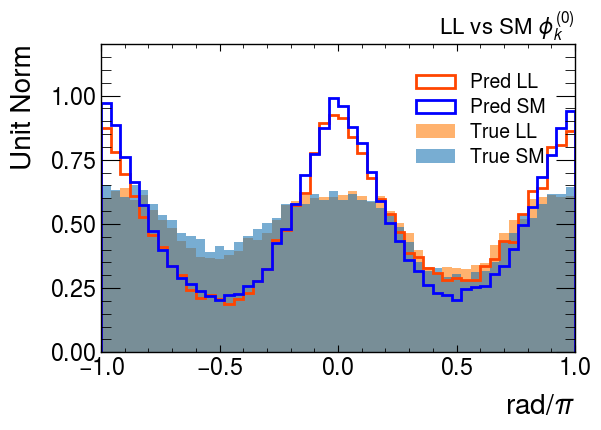

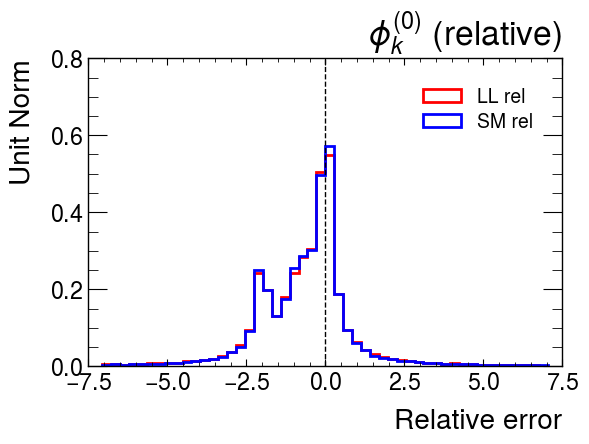

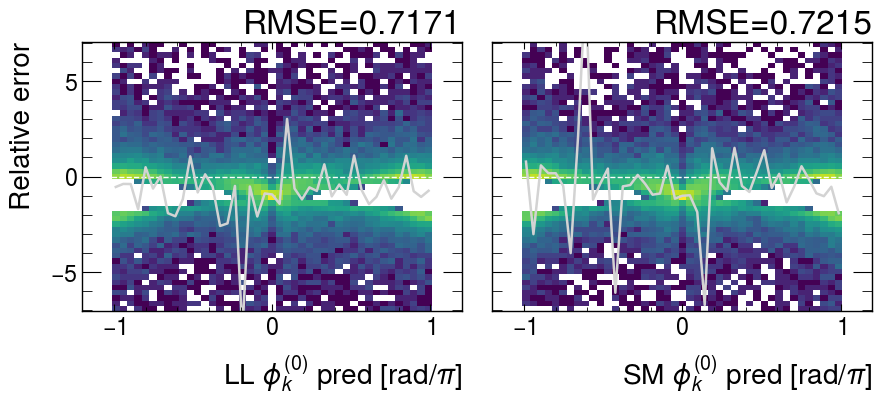

In [ ]:
plot_1d_comparison(pred_l0_theta_phi[1], sm_pred_l0_theta_phi[1], true_l0_theta_phi[1], sm_true_l0_theta_phi[1], "LL vs SM "+r"$\phi^{(0)}_k$", np.linspace(-1, 1, 51), r"rad/$\pi$")
plot_error(
    ll_pred=pred_l0_theta_phi[1],
    ll_true=true_l0_theta_phi[1],
    sm_pred=sm_pred_l0_theta_phi[1],
    sm_true=sm_true_l0_theta_phi[1],
    name=r"$\phi^{(0)}_k$",
    units=r"[rad/$\pi$]",
    pred_range=(-1.2, 1.2),
    # residual_y_range=(-2.2, 2.2),
)


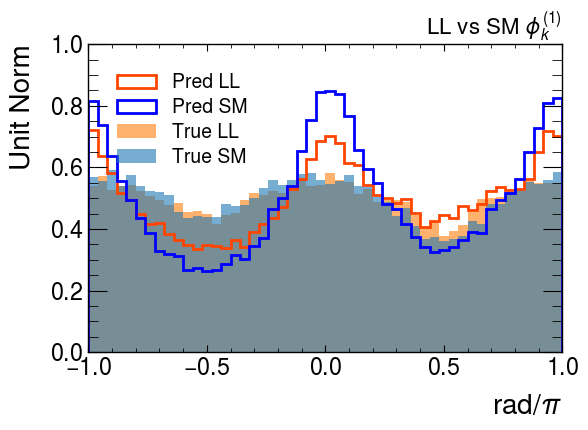

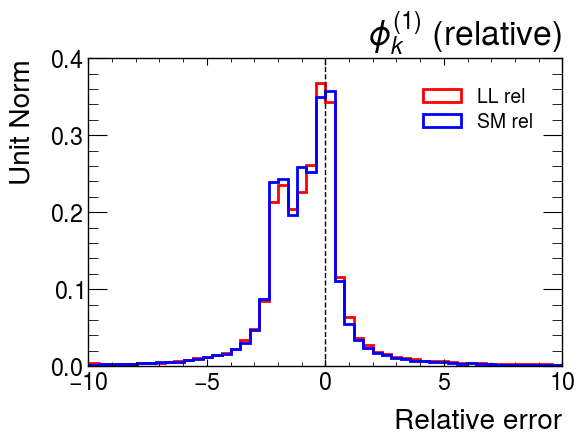

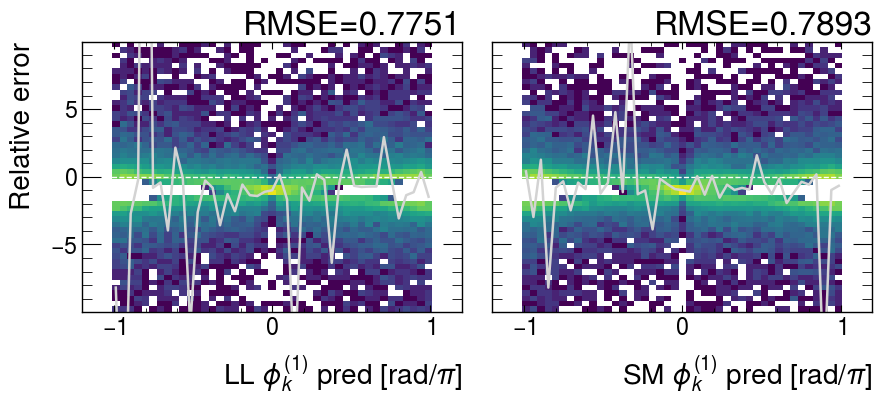

In [ ]:
plot_1d_comparison(pred_l1_theta_phi[1], sm_pred_l1_theta_phi[1], true_l1_theta_phi[1], sm_true_l1_theta_phi[1], "LL vs SM "+r"$\phi^{(1)}_k$", np.linspace(-1, 1, 51), r"rad/$\pi$")
plot_error(
    ll_pred=pred_l1_theta_phi[1],
    ll_true=true_l1_theta_phi[1],
    sm_pred=sm_pred_l1_theta_phi[1],
    sm_true=sm_true_l1_theta_phi[1],
    name=r"$\phi^{(1)}_k$",
    units=r"[rad/$\pi$]",
    pred_range=(-1.2, 1.2),
    # residual_y_range=(-2.2, 2.2),
)


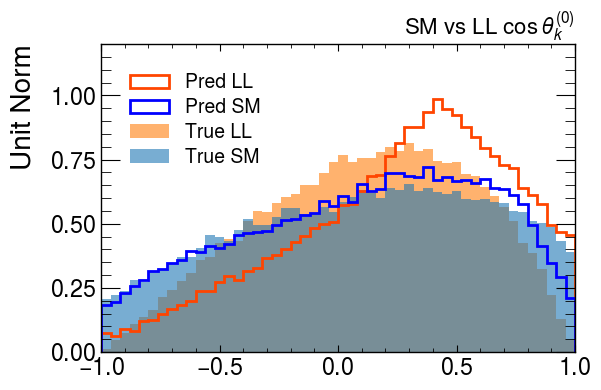

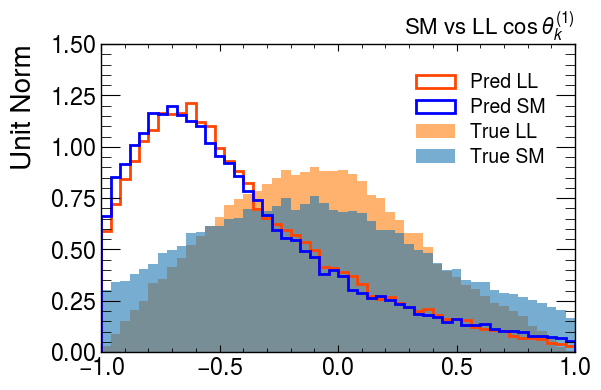

In [ ]:
plot_1d_comparison(np.cos( np.pi * pred_l0_theta_phi[0]), np.cos( np.pi * sm_pred_l0_theta_phi[0]), np.cos( np.pi * true_l0_theta_phi[0]), np.cos( np.pi * sm_true_l0_theta_phi[0]), "SM vs LL "+r"$\cos \theta^{(0)}_k$", np.linspace(-1, 1, 51))
plot_1d_comparison(np.cos( np.pi * pred_l1_theta_phi[0]), np.cos( np.pi * sm_pred_l1_theta_phi[0]), np.cos( np.pi * true_l1_theta_phi[0]), np.cos( np.pi * sm_true_l1_theta_phi[0]), "SM vs LL "+r"$\cos \theta^{(1)}_k$", np.linspace(-1, 1, 51))

In [ ]:
true_higgs_px = true_w0_px + true_w1_px
true_higgs_py = true_w0_py + true_w1_py
true_higgs_pz = true_w0_pz + true_w1_pz
true_higgs_energy = true_w0_energy + true_w1_energy
pred_higgs_energy = pred_w0_energy + pred_w1_energy
pred_higgs_pz = pred_w0_pz + pred_w1_pz
pred_higgs_py = pred_w0_py + pred_w1_py
pred_higgs_px = pred_w0_px + pred_w1_px

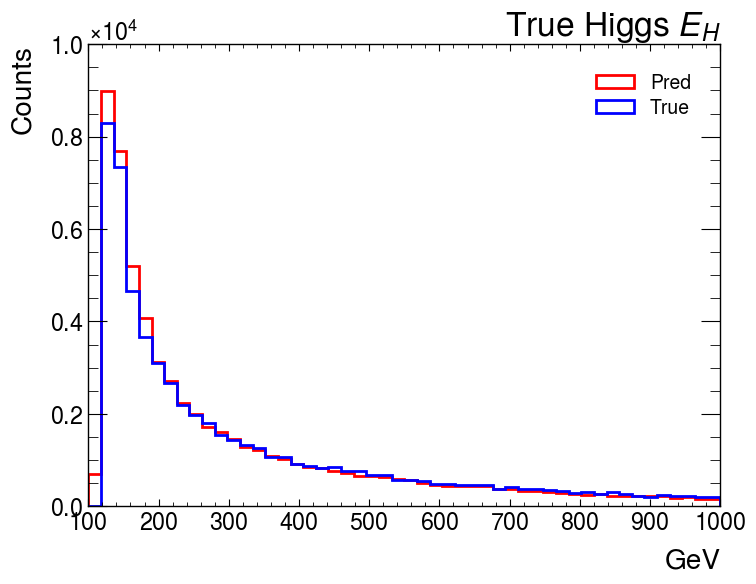

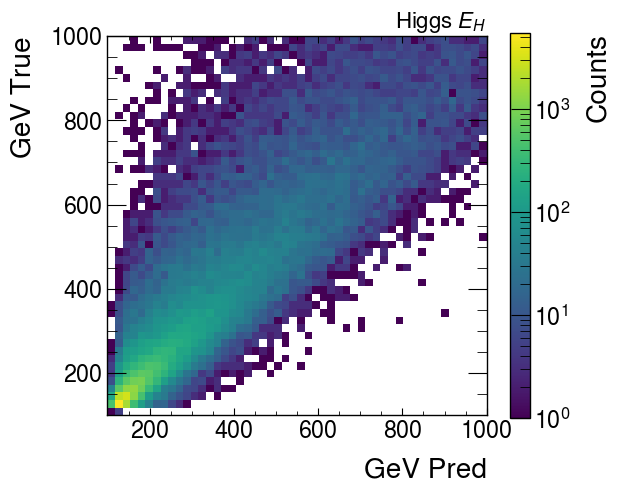

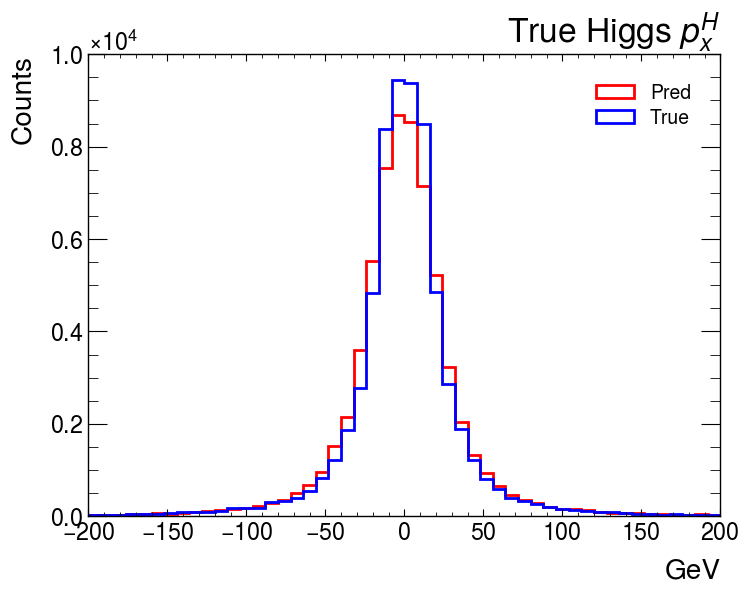

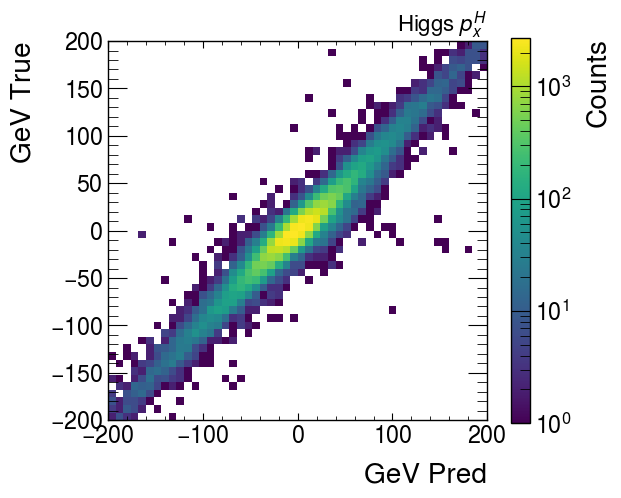

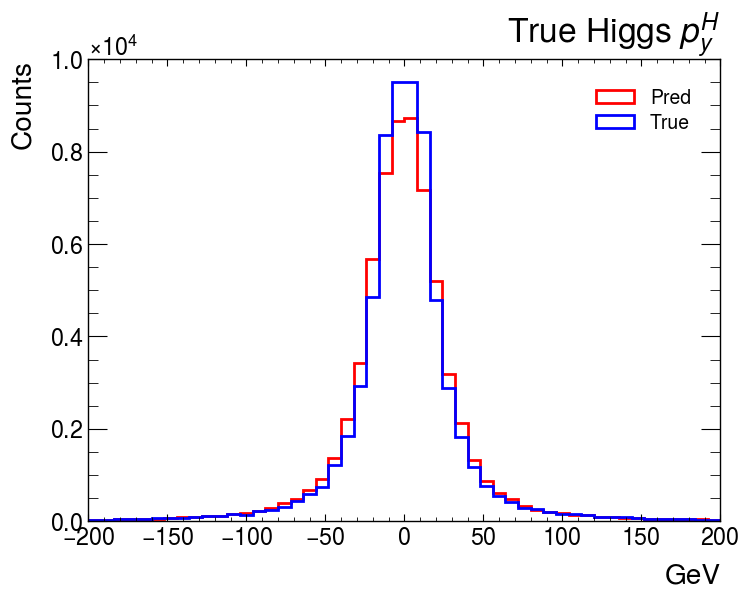

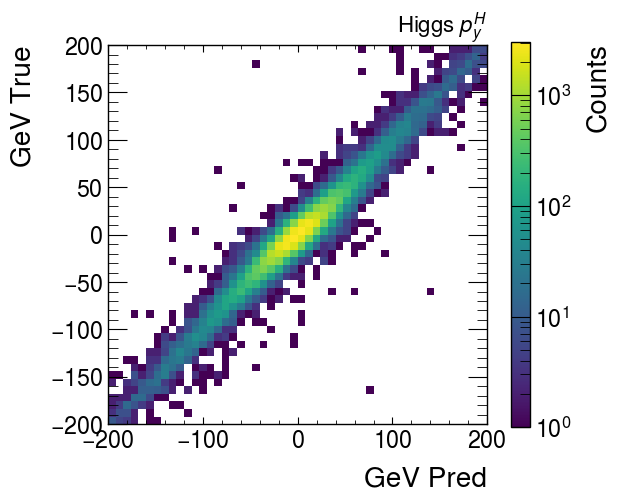

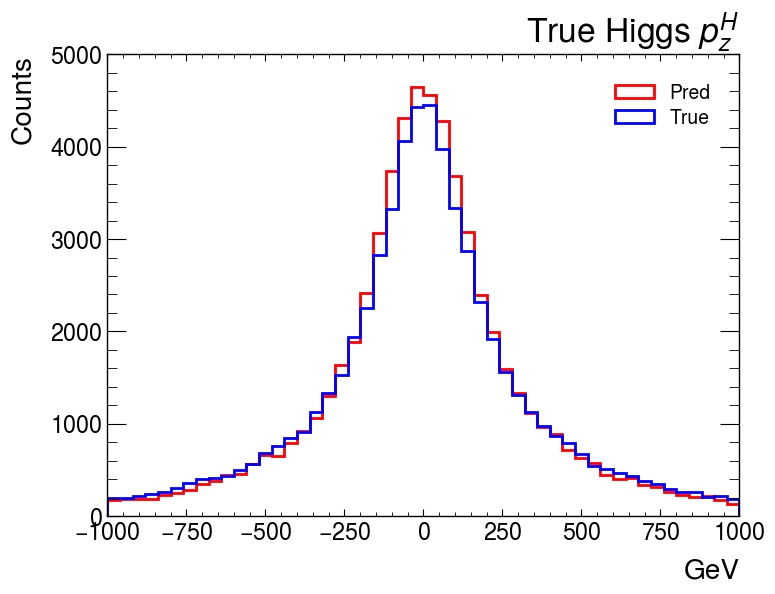

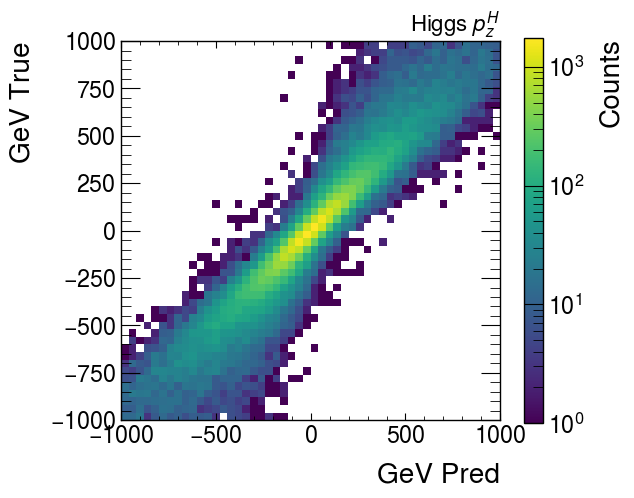

In [ ]:
plot_1d_hist(pred_higgs_energy, true_higgs_energy, name="True Higgs "+r"$E_H$", bins_edges=np.linspace(100, 1000, 51))
plot_2d(pred_higgs_energy, true_higgs_energy, "Higgs "+r"$E_H$", np.linspace(100, 1000, 51), np.linspace(100, 1000, 51), units="GeV")
plot_1d_hist(pred_higgs_px, true_higgs_px, name="True Higgs "+r"$p_{x}^{H}$", bins_edges=np.linspace(-200, 200, 51))
plot_2d(pred_higgs_px, true_higgs_px, "Higgs "+r"$p_{x}^{H}$", np.linspace(-200, 200, 51), np.linspace(-200, 200, 51), units="GeV")
plot_1d_hist(pred_higgs_py, true_higgs_py, name="True Higgs "+r"$p_{y}^{H}$", bins_edges=np.linspace(-200, 200, 51))
plot_2d(pred_higgs_py, true_higgs_py, "Higgs "+r"$p_{y}^{H}$", np.linspace(-200, 200, 51), np.linspace(-200, 200, 51), units="GeV")
plot_1d_hist(pred_higgs_pz, true_higgs_pz, name="True Higgs "+r"$p_{z}^{H}$", bins_edges=np.linspace(-1000, 1000, 51))
plot_2d(pred_higgs_pz, true_higgs_pz, "Higgs "+r"$p_{z}^{H}$", np.linspace(-1000, 1000, 51), np.linspace(-1000, 1000, 51), units="GeV")

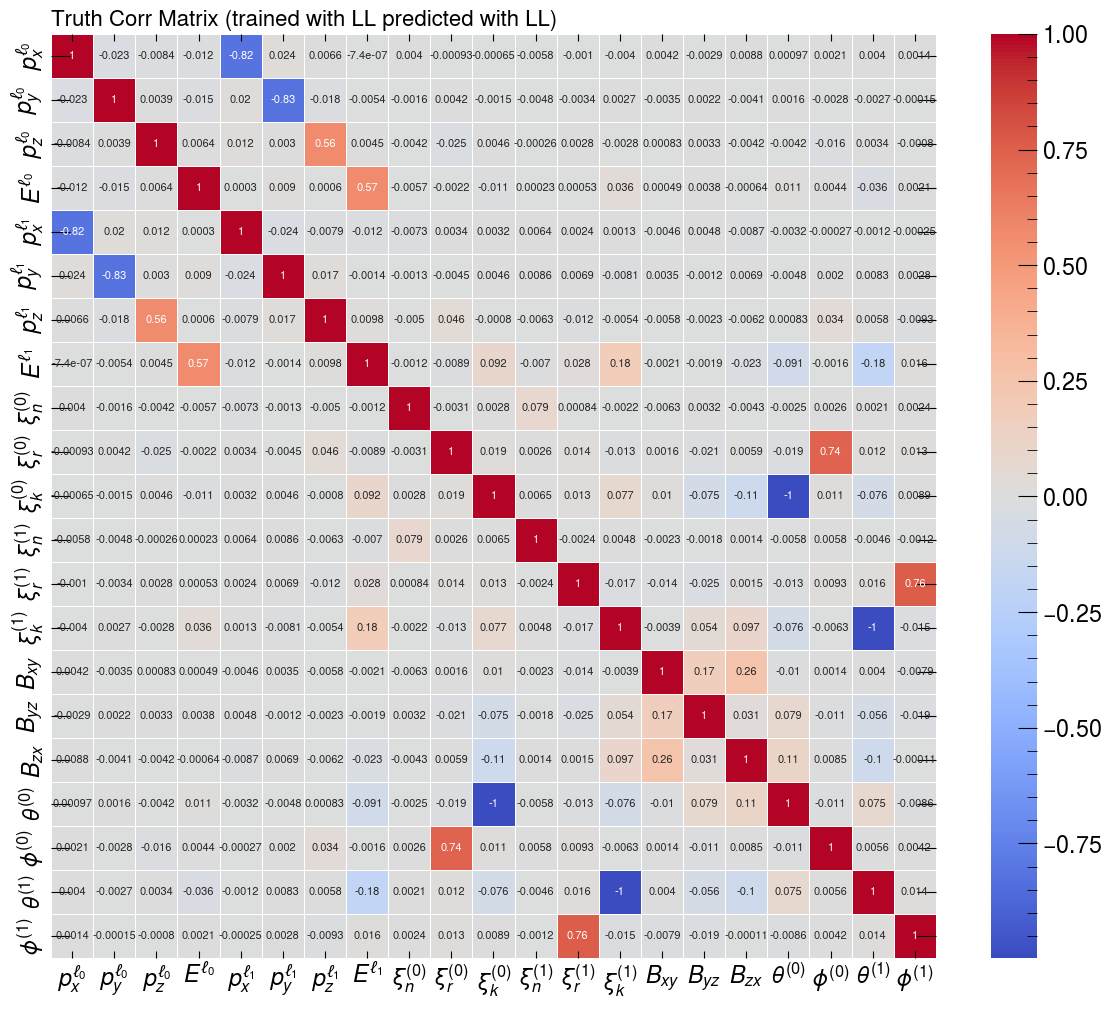

In [ ]:
data = {
    r"$p_{x}^{\ell_0}$": true_w0_px[:50_000],
    r"$p_{y}^{\ell_0}$": true_w0_py[:50_000],
    r"$p_{z}^{\ell_0}$": true_w0_pz[:50_000],
    r"$E^{\ell_0}$": true_w0_energy[:50_000],
    r"$p_{x}^{\ell_1}$": true_w1_px[:50_000],
    r"$p_{y}^{\ell_1}$": true_w1_py[:50_000],
    r"$p_{z}^{\ell_1}$": true_w1_pz[:50_000],
    r"$E^{\ell_1}$": true_w1_energy[:50_000],
    r"$\xi^{(0)}_n$": true_xi_pos[0][:50_000],
    r"$\xi^{(0)}_r$": true_xi_pos[1][:50_000],
    r"$\xi^{(0)}_k$": true_xi_pos[2][:50_000],
    r"$\xi^{(1)}_n$": true_xi_neg[0][:50_000],
    r"$\xi^{(1)}_r$": true_xi_neg[1][:50_000],
    r"$\xi^{(1)}_k$": true_xi_neg[2][:50_000],
    r"$B_{xy}$": true_cglmp_bij[0][:50_000],
    r"$B_{yz}$": true_cglmp_bij[1][:50_000],
    r"$B_{zx}$": true_cglmp_bij[2][:50_000],
    r"$\theta^{(0)}$": true_l0_theta_phi[0][:50_000],
    r"$\phi^{(0)}$": true_l0_theta_phi[1][:50_000],
    r"$\theta^{(1)}$": true_l1_theta_phi[0][:50_000],
    r"$\phi^{(1)}$": true_l1_theta_phi[1][:50_000],
}
df = pd.DataFrame(data)

# Compute correlation matrix
corr_matrix = df.corr()

# Visualize it

plt.figure(figsize=(14,12))
sns.heatmap(
    corr_matrix, 
    annot=True,
    cmap="coolwarm", 
    linewidths=0.5,
    annot_kws={"size": 8}
)
plt.minorticks_off()
plt.title("Truth Corr Matrix (trained with LL predicted with LL)", size=16, loc="left")
plt.show()

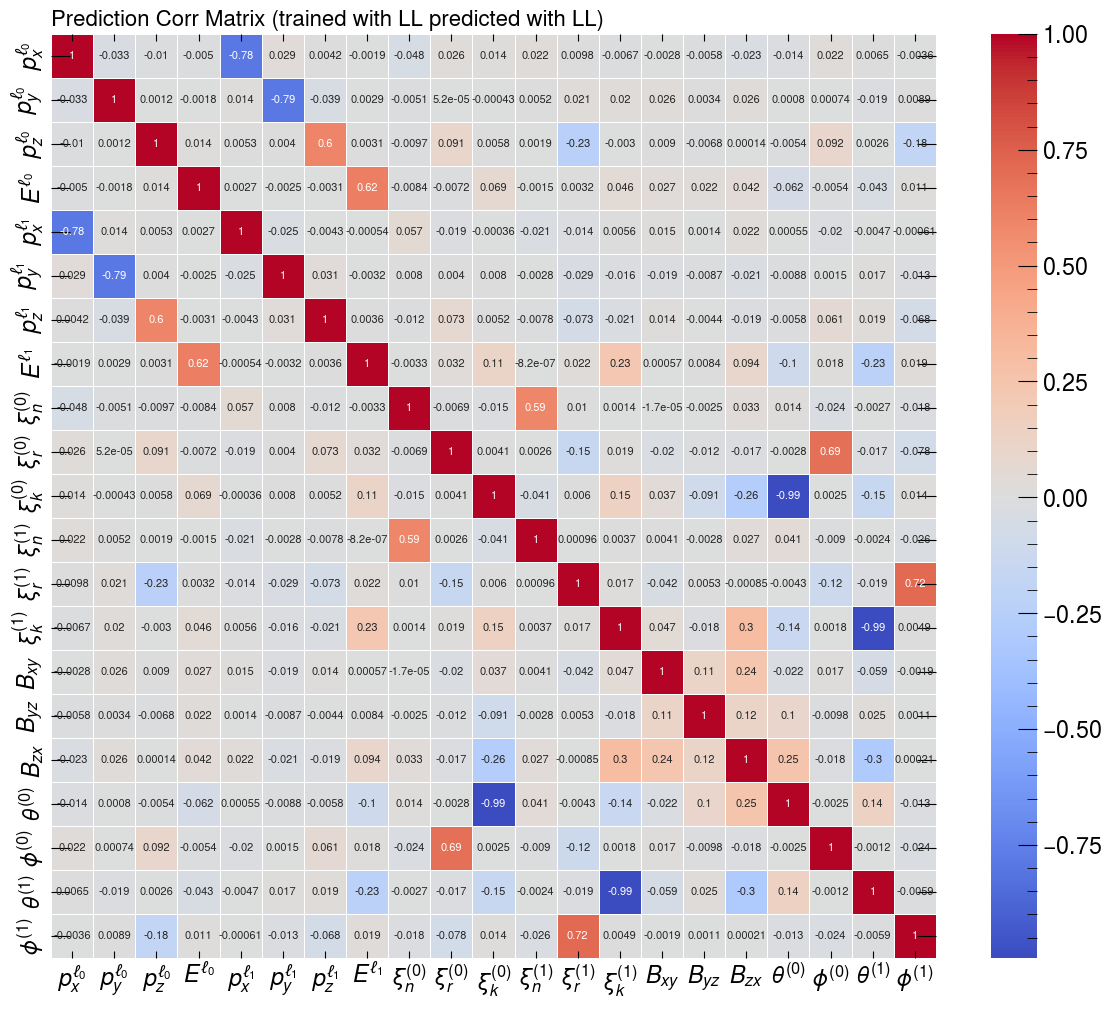

In [ ]:
data = {
    r"$p_{x}^{\ell_0}$": pred_w0_px[:50_000],
    r"$p_{y}^{\ell_0}$": pred_w0_py[:50_000],
    r"$p_{z}^{\ell_0}$": pred_w0_pz[:50_000],
    r"$E^{\ell_0}$": pred_w0_energy[:50_000],
    r"$p_{x}^{\ell_1}$": pred_w1_px[:50_000],
    r"$p_{y}^{\ell_1}$": pred_w1_py[:50_000],
    r"$p_{z}^{\ell_1}$": pred_w1_pz[:50_000],
    r"$E^{\ell_1}$": pred_w1_energy[:50_000],
    r"$\xi^{(0)}_n$": pred_xi_pos[0][:50_000],
    r"$\xi^{(0)}_r$": pred_xi_pos[1][:50_000],
    r"$\xi^{(0)}_k$": pred_xi_pos[2][:50_000],
    r"$\xi^{(1)}_n$": pred_xi_neg[0][:50_000],
    r"$\xi^{(1)}_r$": pred_xi_neg[1][:50_000],
    r"$\xi^{(1)}_k$": pred_xi_neg[2][:50_000],
    r"$B_{xy}$": pred_cglmp_bij[0][:50_000],
    r"$B_{yz}$": pred_cglmp_bij[1][:50_000],
    r"$B_{zx}$": pred_cglmp_bij[2][:50_000],
    r"$\theta^{(0)}$": pred_l0_theta_phi[0][:50_000],
    r"$\phi^{(0)}$": pred_l0_theta_phi[1][:50_000],
    r"$\theta^{(1)}$": pred_l1_theta_phi[0][:50_000],
    r"$\phi^{(1)}$": pred_l1_theta_phi[1][:50_000],
}
df = pd.DataFrame(data)

# Compute correlation matrix
corr_matrix = df.corr()

# Visualize it
plt.figure(figsize=(14,12))
sns.heatmap(
    corr_matrix, 
    annot=True,
    cmap="coolwarm", 
    linewidths=0.5,
    annot_kws={"size": 8}
)
plt.minorticks_off()
plt.title("Prediction Corr Matrix (trained with LL predicted with LL)", size=16, loc="left")
plt.show()

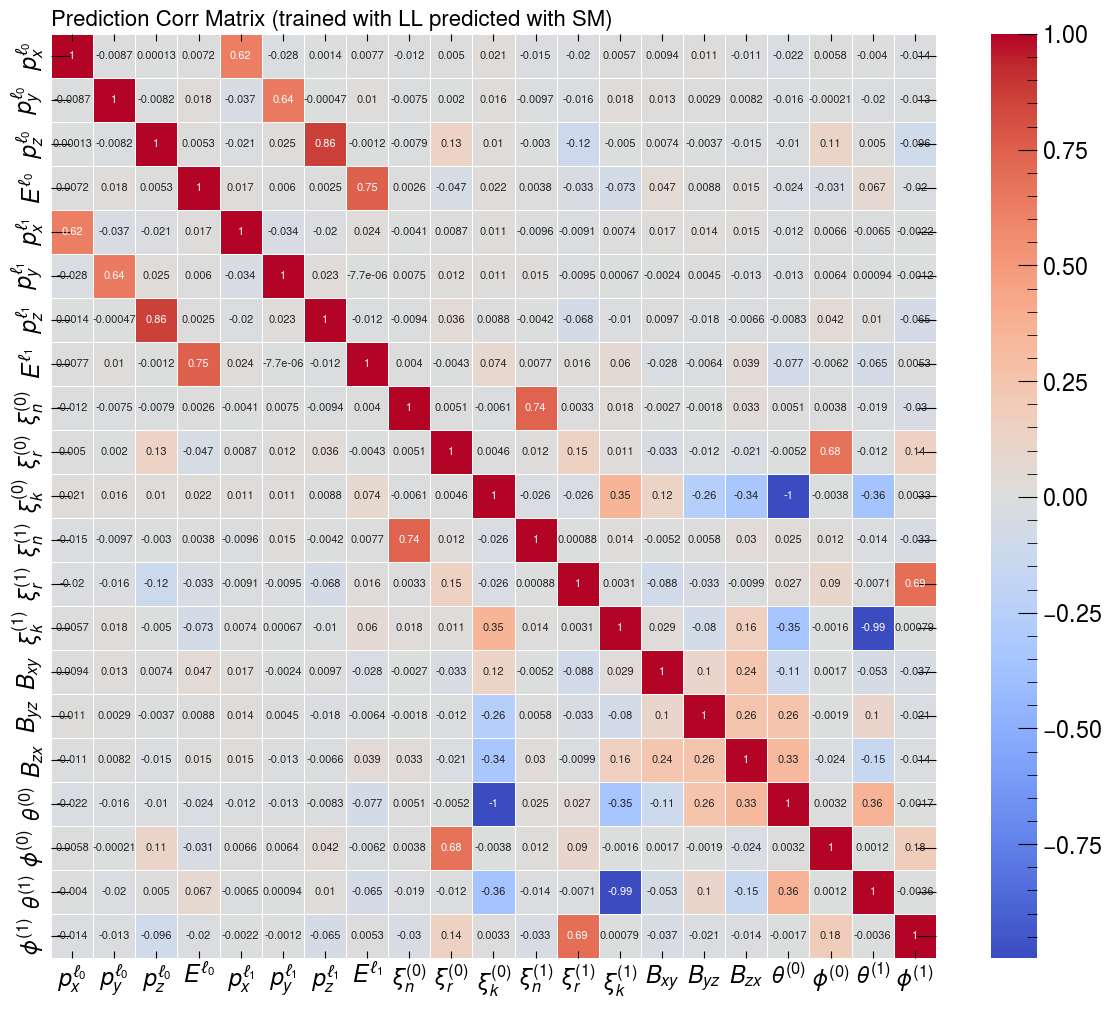

In [ ]:
data = {
    r"$p_{x}^{\ell_0}$": sm_pred_w0_px[:50_000],
    r"$p_{y}^{\ell_0}$": sm_pred_w0_py[:50_000],
    r"$p_{z}^{\ell_0}$": sm_pred_w0_pz[:50_000],
    r"$E^{\ell_0}$": sm_pred_w0_energy[:50_000],
    r"$p_{x}^{\ell_1}$": sm_pred_w1_px[:50_000],
    r"$p_{y}^{\ell_1}$": sm_pred_w1_py[:50_000],
    r"$p_{z}^{\ell_1}$": sm_pred_w1_pz[:50_000],
    r"$E^{\ell_1}$": sm_pred_w1_energy[:50_000],
    r"$\xi^{(0)}_n$": sm_pred_xi_pos[0][:50_000],
    r"$\xi^{(0)}_r$": sm_pred_xi_pos[1][:50_000],
    r"$\xi^{(0)}_k$": sm_pred_xi_pos[2][:50_000],
    r"$\xi^{(1)}_n$": sm_pred_xi_neg[0][:50_000],
    r"$\xi^{(1)}_r$": sm_pred_xi_neg[1][:50_000],
    r"$\xi^{(1)}_k$": sm_pred_xi_neg[2][:50_000],
    r"$B_{xy}$": sm_pred_cglmp_bij[0][:50_000],
    r"$B_{yz}$": sm_pred_cglmp_bij[1][:50_000],
    r"$B_{zx}$": sm_pred_cglmp_bij[2][:50_000],
    r"$\theta^{(0)}$": sm_pred_l0_theta_phi[0][:50_000],
    r"$\phi^{(0)}$": sm_pred_l0_theta_phi[1][:50_000],
    r"$\theta^{(1)}$": sm_pred_l1_theta_phi[0][:50_000],
    r"$\phi^{(1)}$": sm_pred_l1_theta_phi[1][:50_000],
}
df = pd.DataFrame(data)

# Compute correlation matrix
corr_matrix = df.corr()

# Visualize it
plt.figure(figsize=(14,12))
sns.heatmap(
    corr_matrix, 
    annot=True,
    cmap="coolwarm", 
    linewidths=0.5,
    annot_kws={"size": 8}
)
plt.minorticks_off()
plt.title("Prediction Corr Matrix (trained with LL predicted with SM)", size=16, loc="left")
plt.show()